In [1]:
# Theoretical and Real AVO analysis using raw seismic data from KOPRI
# Zachary Katz
# 27 November 2025

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from obspy.io.segy.core import _read_segy
import os
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import rasterio
############
# Number of shots on this Line [X=56, Y=40, XX=28. YY=20]
line = '21Y'
geometry_path = './_data/KPDC_David_Seismic_2022/RAW/21Y-Geometry.csv' 
sgy_file = './_data/KPDC_David_Seismic_2022/RAW/21Y'
############

geometry = pd.read_csv(geometry_path)
num_shots = np.max(geometry["SHOT_POINT"])

sgy_path = sgy_file + '.sgy'


In [2]:

def segyload_obspy(sgy_path, fldr_number=1):
    # Load entire SEG-Y file
    st = _read_segy(sgy_path, unpack_trace_headers=True)

    # Sampling values
    dt = st[0].stats.delta          # seconds
    ns = st[0].stats.npts
    time = np.arange(ns) * dt       # seconds

    # Select traces based on Field Record Number (fldr)
    selected_traces = []
    coords = {'source_x': [], 'source_y': [], 'group_x': [], 'group_y': []}
    for tr in st:
        hdr = tr.stats.segy.trace_header
        if hdr.original_field_record_number == fldr_number:
            selected_traces.append(tr.data)
            coords['source_x'].append(hdr.source_coordinate_x)
            coords['source_y'].append(hdr.source_coordinate_y)
            coords['group_x'].append(hdr.group_coordinate_x)
            coords['group_y'].append(hdr.group_coordinate_y)

    #if len(selected_traces) == 0:
    #    raise ValueError(f"No traces found for fldr={fldr_number}")

    data = np.stack(selected_traces)
    n_traces = data.shape[0]
    

    # Percentile clipping
    #lower_clip = np.percentile(data, 0.05)
    #upper_clip = np.percentile(data, 99.95)
    #data_clipped = np.clip(data, lower_clip, upper_clip)
    data_clipped = data

    # Transpose to (ns, n_traces) like segyio version
    data_clipped = data_clipped.T

    return data_clipped, time, n_traces, coords


data_arr = {'data_clipped': [], 'time': [], 'n_traces': [], 'coords': []}
for fldr_number in range(1,num_shots+1):
    print(fldr_number)
    data_clipped, time, n_traces, coords = segyload_obspy(sgy_path, fldr_number)
    data_arr['data_clipped'].append(data_clipped)
    data_arr['time'].append(time)
    data_arr['n_traces'].append(n_traces)
    data_arr['coords'].append(coords)


1
2
3
4
5
6


KeyboardInterrupt: 

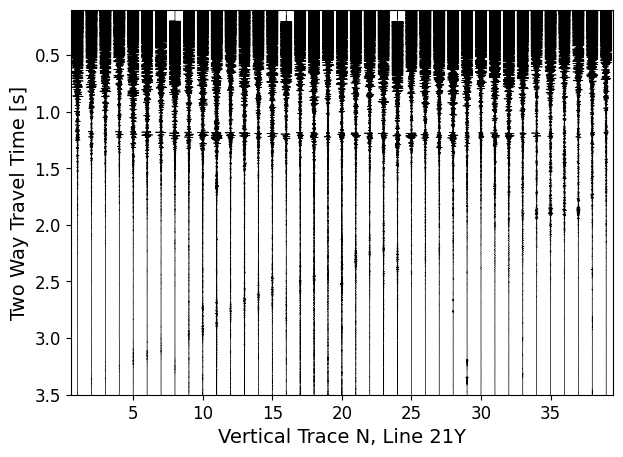

In [2]:
fig, ax = plt.subplots(figsize=(7, 5))
for index, fldr_number in enumerate(range(2,num_shots+1)):
    subset_geometry = geometry[geometry["SHOT_POINT"] == fldr_number].reset_index(drop=True)
    dist = np.array([np.sqrt((subset_geometry['XSHOT'][i]-subset_geometry['XREC'][i])**2 + (subset_geometry['YSHOT'][i]-subset_geometry['YREC'][i])**2 ) for i in range(len(subset_geometry['XSHOT']))])
    # Extract the correct shot to plot
    min_idx = np.argmin(dist) 

    vert_trace = data_arr['data_clipped'][index][:,min_idx]
    # clip vertical trace to be +/- 1
    #vert_trace = vert_trace * 2
    vert_trace = np.clip(vert_trace, -0.4, 0.4)
    x = index * np.ones_like(vert_trace) + vert_trace + 1
    time = data_arr['time'][index]

    ax.plot(x, time, color='k', linewidth=0.5)
    ax.set_xlim(0.5,39.5)
    ax.set_ylim(3.5,0.1)
    ax.set_xlabel("Vertical Trace N, Line 21Y",fontsize=14)
    ax.set_ylabel("Two Way Travel Time [s]",fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)


In [3]:
data_arr['data_clipped'][0].shape
line = '21YY'

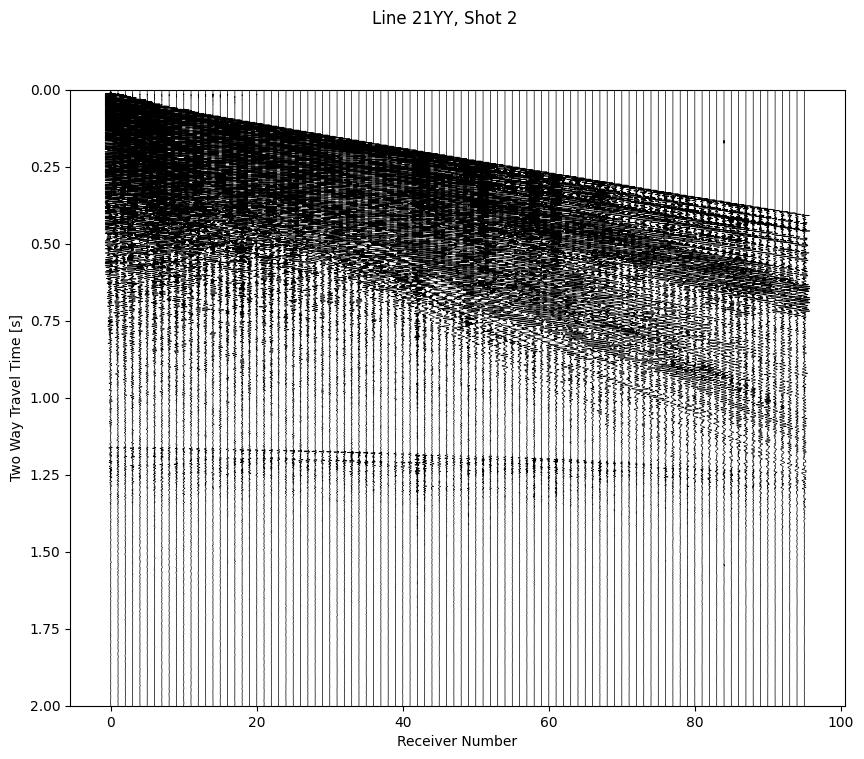

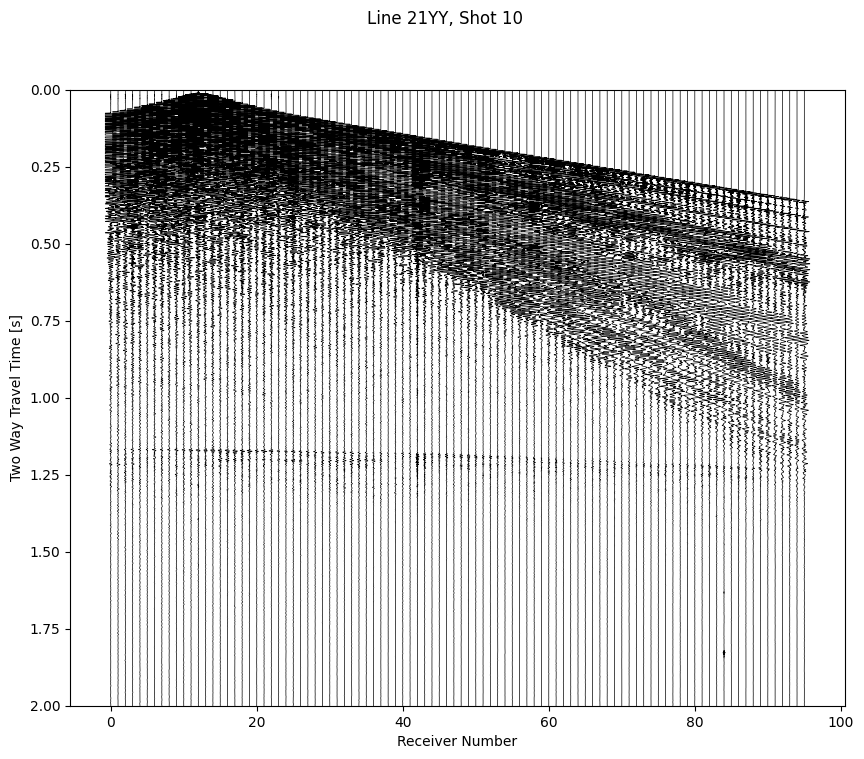

In [64]:
for index, fldr_number in enumerate([2,10]):
    fig, ax = plt.subplots(figsize=(10, 8))
    subset_geometry = geometry[geometry["SHOT_POINT"] == fldr_number].reset_index(drop=True)

    time = data_arr['time'][index]
    traces = data_arr['data_clipped'][index]
    for trace_no, trace in enumerate(traces.T):
        trace = np.clip(trace, -0.75, 0.75)
        x = trace_no * np.ones_like(trace) + trace
        ax.plot(x, time, color='k', linewidth=0.5)

    ax.set_ylim(2,0)
    #ax.set_ylim(1.5,1)
    ax.set_xlabel("Receiver Number")
    ax.set_ylabel("Two Way Travel Time [s]")
    fig.suptitle(f"Line {line}, Shot {fldr_number}")


In [2]:
from PyAstronomy import pyasl

gnss1 = pyasl.decimalYearGregorianDate(2018.87897)
gnss2 = pyasl.decimalYearGregorianDate(2018.88034)
gnssN = pyasl.decimalYearGregorianDate(2019.85091)
print(gnss1, gnss2, gnssN)

2018-11-17 19:46:37.000920 2018-11-18 07:46:42.000240 2019-11-07 13:58:17.000760


In [3]:
file_path = './_data/GNSS'
gnss_records = []
for file in os.listdir(file_path):
    if file.endswith('.txt'):
        gnss_data = pd.read_csv(f'{file_path}/{file}',header=0, names=['time','x','y','z','detrended_z','v'])
        gnss_data['datetime'] = [pyasl.decimalYearGregorianDate(time) for time in gnss_data['time']]
        x0 = gnss_data['x'].iloc[0]
        y0 = gnss_data['y'].iloc[0]

        gnss_data['h_displacement'] = np.sqrt(
            (gnss_data['x'] - x0)**2 +
            (gnss_data['y'] - y0)**2
        )
        station = file.split('.')[0]
        gnss_data['station'] = station
        gnss_records.append(gnss_data)

gnss_records = sorted(gnss_records, key=lambda x: x['station'][0])

In [4]:
import shapefile
import cartopy.crs as ccrs
from pyproj import CRS, Transformer
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib as mpl

def ll2xy(lon: list[float], lat: list[float]) -> tuple[list[float], list[float]]:
    """
    Transform coordinates from input geodetic coordinates (lon, lat)
    to output Antarctic Polar Stereographic coordinates (x, y).
    Can also take single floats.

    Parameters
    ----------
    lon: list[float]
         Geodetic longitude in EPSG:4326
    lat: list[float]
         Geodetic latitude in EPSG:4326

    Returns
    -------
    x: list[float]
       Antarctic Polar Stereographic (EPSG:3031) x
    y: list[float]
       Antarctic Polar Stereographic (EPSG:3031) y
    """

    crs_ll = CRS("EPSG:4326")
    crs_xy = CRS("EPSG:3031")
    ll_to_xy = Transformer.from_crs(crs_ll, crs_xy, always_xy=True)
    x, y = ll_to_xy.transform(lon, lat)
    return x, y

/tmp/ipykernel_29347/255433160.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("magma")
/tmp/ipykernel_29347/255433160.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("magma")
/tmp/ipykernel_29347/255433160.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("magma")


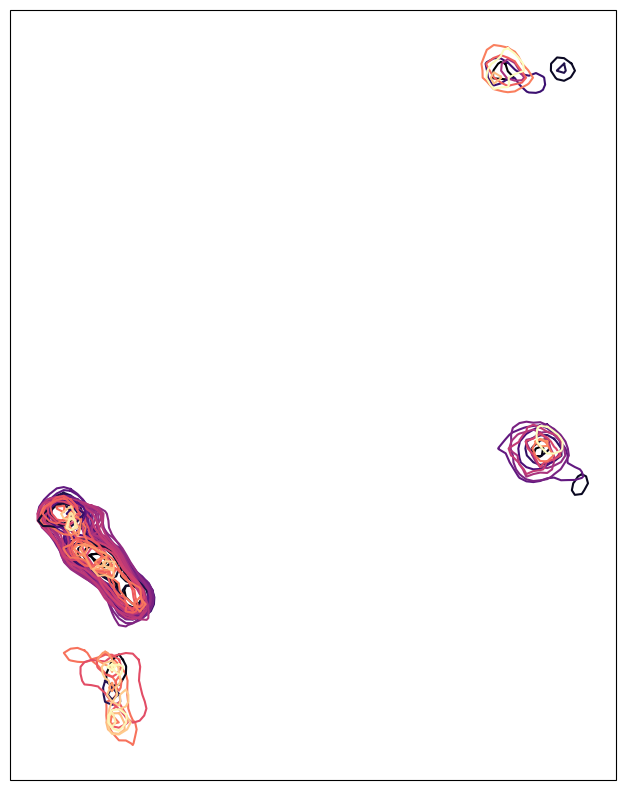

In [5]:
# Load Wilson Outline for SLD1,2
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.colors as colors

ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig, ax = plt.subplots(
    figsize=(10, 10),
    subplot_kw={'projection': ps71_projection},
)

paths = ['./_data/EvolvingOutlines/David_s1.geojson','./_data/EvolvingOutlines/David_s2.geojson','./_data/EvolvingOutlines/David_s3.geojson']
for evolving_path in paths:
    evolving_outlines = gpd.read_file(evolving_path)
    times = evolving_outlines["mid_pt_datetime"]

    # Convert datetimes → numeric (float seconds)
    t_num = np.array(times.astype("int64"))  # nanoseconds since epoch

    # Normalize to 0–1 range for the colormap
    norm = colors.Normalize(vmin=t_num.min(), vmax=t_num.max())
    cmap = cm.get_cmap("magma")


    for outline, time in zip(evolving_outlines['geometry'], t_num):
        x_evolve, y_evolve = outline.exterior.xy
        color = cmap(norm(time))
        ax.plot(x_evolve, y_evolve, color=color)


In [6]:
from impdar.lib import load, plot # Use obspy instead as segy
# Load with impdar
file_paths_18_19 = [os.path.join('../david_radar/_data/IPR_2018-2019', f) for f in os.listdir('../david_radar/_data/IPR_2018-2019') if f.endswith('.segy')]
file_paths_18_19.sort()
radargrams_18_19 = [load.load('segy',file_paths_18_19[i]) for i in range(len(file_paths_18_19[:]))]



In [45]:
# Load with impdar
file_paths_16_17 = [os.path.join('../david_radar/_data/IPR_2016-2017', f) for f in os.listdir('../david_radar/_data/IPR_2016-2017') if f.endswith('.segy')]
#file_paths_16_17 = [os.path.join('/mnt/c/users/ZacharyKatz/Desktop/JuIPR/KRT1/SGY_(w_GPS)', f) for f in os.listdir('/mnt/c/users/ZacharyKatz/Desktop/JuIPR/KRT1/SGY_(w_GPS)') if f.endswith('.segy')]
file_paths_16_17.sort()
radargrams_16_17 = [load.load('segy',file_paths_16_17[i]) for i in range(len(file_paths_16_17[:20]))]

names_1819 = [path.split('/')[-1].split('.')[0] for path in file_paths_18_19]
names_1617 = [path.split('/')[-1].split('.')[0] for path in file_paths_16_17]

In [10]:
# Load utig netcdf
import xarray as xr
utig_paths = [os.path.join('/mnt/c/users/ZacharyKatz/Desktop/UTG_David', f) for f in os.listdir('/mnt/c/users/ZacharyKatz/Desktop/UTG_David') if f.endswith('.nc')]

utig_grams = []
for path in utig_paths:
    utig_radargram = xr.open_mfdataset(path, combine='by_coords')
    utig_radargram['x_coord'], utig_radargram['y_coord'] = ll2xy(utig_radargram['lon'].values, utig_radargram['lat'].values)
    utig_grams.append(utig_radargram)



/tmp/ipykernel_1816/2050476426.py:7: FutureWarning: In a future version, xarray will not decode the variable 'fasttime' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  utig_radargram = xr.open_mfdataset(path, combine='by_coords')
/tmp/ipykernel_1816/2050476426.py:7: FutureWarning: In a future version, xarray will not decode the variable 'fasttime' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding ti

In [6]:
%matplotlib inline

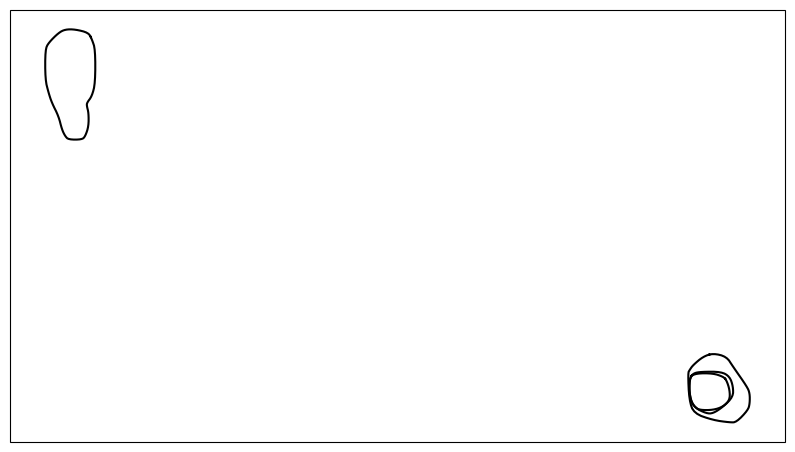

In [7]:
# Load Sarah Wilson Outline
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig, ax = plt.subplots(
    figsize=(10, 10),
    subplot_kw={'projection': ps71_projection},
)

paths = [os.path.join('./_data/SarahWilsonOutlines', f) for f in os.listdir('./_data/SarahWilsonOutlines') if f.endswith('.geojson')]
for evolving_path in paths:
    outline = gpd.read_file(evolving_path)
    # Plot outline geometry
    geom = outline.geometry.iloc[0] 
    for poly in geom.geoms:
        # Convert lat lon to xy
        x,y = ll2xy(*poly.exterior.xy)
        ax.plot(x, y, color="k")


In [13]:
# Load Ju's Bed Picks for plotting
_16_17_bedpick_path = '/mnt/c/users/ZacharyKatz/Desktop/JuIPR/KRT1/total_DVG.xlsx'
_18_19_bedpick_path = '/mnt/c/users/ZacharyKatz/Desktop/JuIPR/KRT2/total_D2DG_7.1.xlsx'
_16_17_bedpicks = pd.read_excel(_16_17_bedpick_path)
_18_19_bedpicks = pd.read_excel(_18_19_bedpick_path)

In [9]:
_16_17_bedpicks

,YEAR,MONTH,DAY,HOUR,MIN,SEC,LAT,LON,AIRCRAFT_ELV,SURFACE_ELV,...,PICKX,PICKY,PICKX_KM,PICKY_KM,TWT_SEC,HYDRO,HYDRO_HEAD,Lice,BRP,R23
0,2017,1,30,0,59,1.085,-74.842172,156.256458,2265.173273,1862.198914,...,666866.0,-1516032.0,666.866,-1516.032,0.00002,16.894589,1722.77,-14.880297,-80.2897,6.651219
1,2017,1,30,0,59,1.341,-74.842244,156.256653,2264.084193,1862.122755,...,666858.0,-1516027.0,666.858,-1516.027,0.00002,16.894521,1722.76,-14.882454,-80.3097,6.586873
2,2017,1,30,0,59,1.596,-74.842315,156.256848,2262.995112,1862.046596,...,666850.0,-1516022.0,666.850,-1516.022,0.00002,16.894453,1722.75,-19.604612,-89.3897,-2.537494
3,2017,1,30,0,59,1.852,-74.842387,156.257043,2261.906032,1861.970437,...,666841.0,-1516017.0,666.841,-1516.017,0.00002,16.894385,1722.75,-16.586771,-87.7697,-0.961882
4,2017,1,30,0,59,2.107,-74.842458,156.257237,2260.803681,1861.871759,...,666833.0,-1516012.0,666.833,-1516.012,0.00002,16.894097,1722.72,-21.208931,-93.0697,-6.306171
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372547,2017,1,30,5,45,59.992,-75.589003,158.830526,1776.460872,1405.397352,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
372548,2017,1,30,5,45,59.994,-75.589002,158.830526,1776.473248,1405.696235,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
372549,2017,1,30,5,45,59.996,-75.589001,158.830527,1776.485624,1405.952214,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
372550,2017,1,30,5,45,59.998,-75.589001,158.830527,1776.497999,1406.208194,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


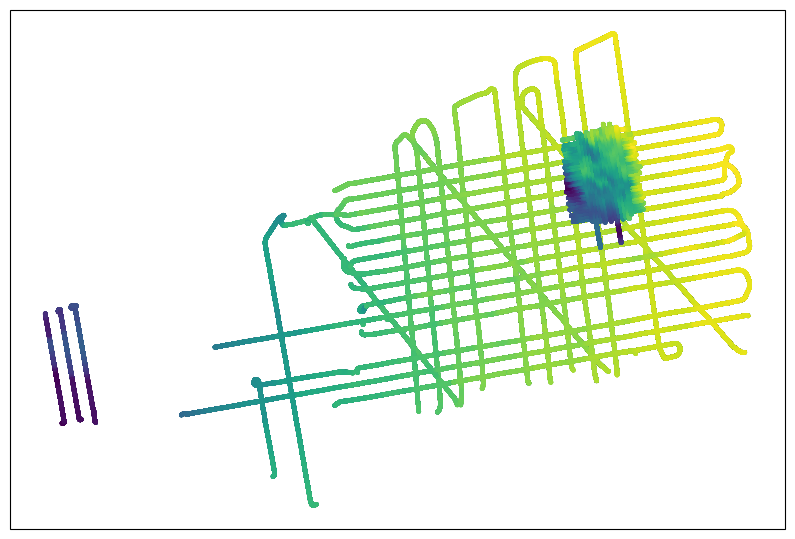

In [29]:
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig, ax = plt.subplots(
    figsize=(10, 10),
    subplot_kw={'projection': ps71_projection},
)

#ax.scatter(_16_17_bedpicks['POLARX'], _16_17_bedpicks['POLARY'], c=_16_17_bedpicks['BED_ELV'], s=5, label='2016-2017 Bed Picks')
#ax.scatter(_18_19_bedpicks['POLARX'], _18_19_bedpicks['POLARY'], c=_18_19_bedpicks['BED_ELV'], s=5, label='2018-2019 Bed Picks')


ax.scatter(_16_17_bedpicks['POLARX'], _16_17_bedpicks['POLARY'], c=_16_17_bedpicks['SURFACE_ELV'], s=5, label='2016-2017 Surface Picks')
ax.scatter(_18_19_bedpicks['POLARX'], _18_19_bedpicks['POLARY'], c=_18_19_bedpicks['SURFACE_ELV'], s=5, label='2018-2019 Surface Picks')

In [33]:
all_vals = np.concatenate([
    _16_17_bedpicks['SURFACE_ELV'].values, #or 'BED_ELV'
    _18_19_bedpicks['SURFACE_ELV'].values
])

norm_radar = plt.Normalize(vmin=np.nanmin(all_vals), vmax=np.nanmax(all_vals))
norm_radar = plt.Normalize(vmin=1400, vmax=2000)
cmap_radar = 'viridis'
print(np.nanmin(all_vals), np.nanmax(all_vals))

-44.464914618931324 2103.8164843140607


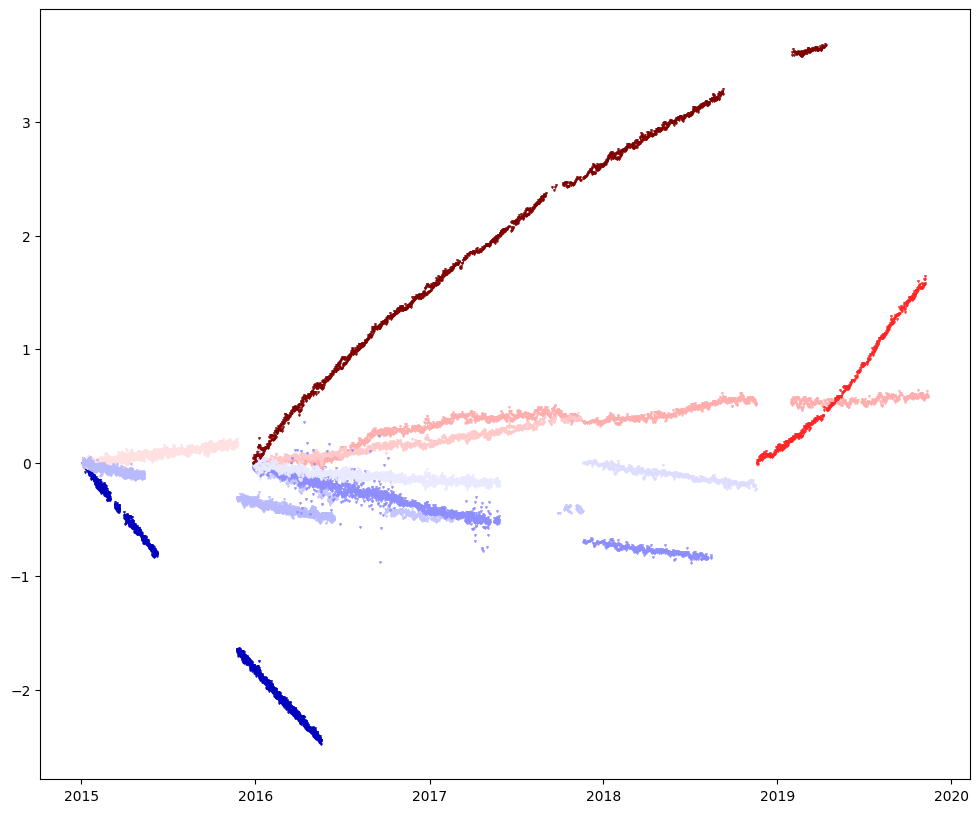

In [31]:
%matplotlib inline


# Change in elevation v time for all stations
final_delta_z = np.array([
    gnss_data['z'].values[np.isfinite(gnss_data['z'].values)][-1]
    - gnss_data['z'].values[np.isfinite(gnss_data['z'].values)][0]
    for gnss_data in gnss_records
])


import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

v = np.nanmax(np.abs(final_delta_z))
norm_gnss = mcolors.TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)
cmap_gnss = plt.cm.seismic
colors_gnss = cmap_gnss(norm_gnss(final_delta_z)) 

fig, ax = plt.subplots(
    figsize=(12, 10),
)
for i, gnss_data in enumerate(gnss_records):
    ax.scatter(gnss_data['datetime'],gnss_data['z']-gnss_data['z'][0],color=colors_gnss[i], marker='v', s=1,zorder=5)

/tmp/ipykernel_29347/3064271406.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("magma")
/tmp/ipykernel_29347/3064271406.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("magma")
/tmp/ipykernel_29347/3064271406.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("magma")


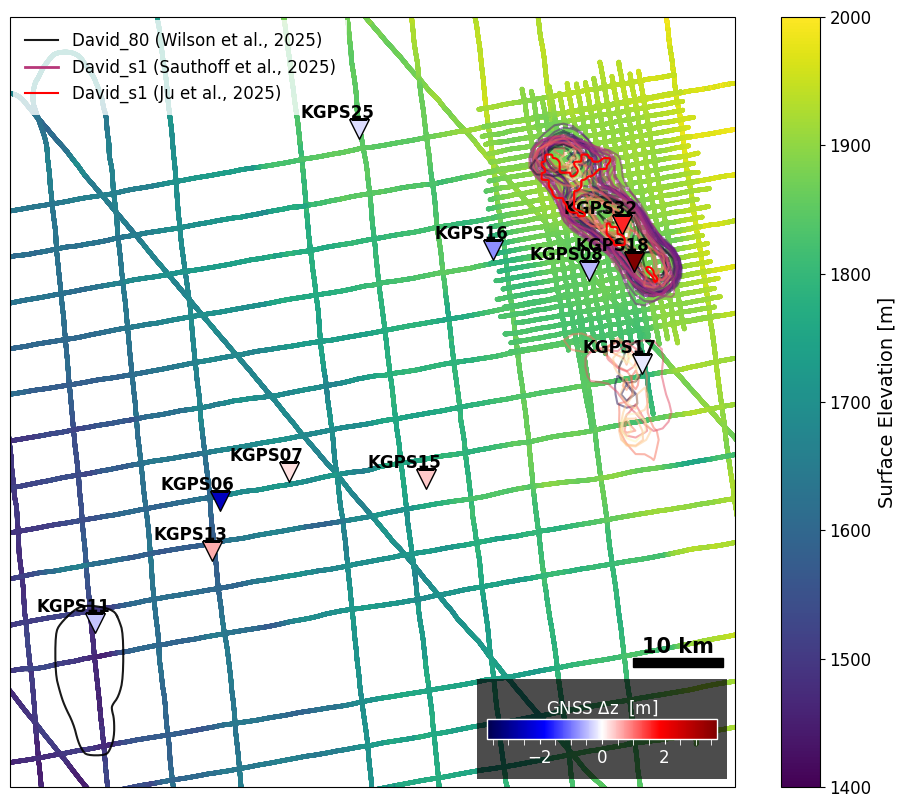

In [34]:
fig_height=10
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig, ax = plt.subplots(
    figsize=(12, 10),
    subplot_kw={'projection': ps71_projection},
)

for clr, gnss_data in zip(colors_gnss, gnss_records):
    #ax.scatter(gnss_data['x'],gnss_data['y'],c=gnss_data['time'])
    ax.scatter(gnss_data['x'][0],gnss_data['y'][0],color=clr, marker='v', s=200,zorder=5,edgecolors= "black")
    ax.text(gnss_data['x'][0]-6500,gnss_data['y'][0]+1200,gnss_data['station'][0], color='black', fontsize=12,zorder=6,fontweight='bold' )

#ax.scatter(seismic['Shot_X'], seismic['Shot_Y'], s=1, c='black', label='Seismic Shots', transform=ps71_projection)
bbox = [615000,-1475000,715000,-1425000] #David_SGL2



paths = ['./_data/EvolvingOutlines/David_s1.geojson','./_data/EvolvingOutlines/David_s2.geojson','./_data/EvolvingOutlines/David_s3.geojson']
for evolving_path in paths:
    evolving_outlines = gpd.read_file(evolving_path)
    times = evolving_outlines["mid_pt_datetime"]

    # Convert datetimes → numeric (float seconds)
    t_num = np.array(times.astype("int64"))  # nanoseconds since epoch
        
    norm = colors.Normalize(vmin=t_num.min(), vmax=t_num.max())
    cmap = cm.get_cmap("magma")

    for outline, time in zip(evolving_outlines['geometry'], t_num):
        x_evolve, y_evolve = outline.exterior.xy
        color = cmap(norm(time))
        ax.plot(x_evolve, y_evolve, color=color,zorder=3,alpha=0.5)


# Plot radargram trace locations
#for radargram in radargrams_18_19[:]:
#    ax.scatter(radargram[0].x_coord*1, radargram[0].y_coord*1, s=0.01, color='gray', zorder=0,alpha=0.1)
#    ax.text(radargram[0].x_coord[0]*1, radargram[0].y_coord[0]*1, names_1819[radargrams_18_19.index(radargram)], color='black', fontsize=10, transform=ps71_projection, zorder=4)

#for utig_radargram in utig_grams:
#    ax.scatter(utig_radargram['x_coord'], utig_radargram['y_coord'], s=0.01, color='gray', zorder=0,alpha=0.1)


paths = [os.path.join('./_data/SarahWilsonOutlines', f) for f in os.listdir('./_data/SarahWilsonOutlines') if f.endswith('David_80_201202-202007_0.3.geojson')]
for evolving_path in paths:
    outline = gpd.read_file(evolving_path)
    # Plot outline geometry
    geom = outline.geometry.iloc[0] 
    for poly in geom.geoms:
        x,y = ll2xy(*poly.exterior.xy)
        ax.plot(x, y, color="k", zorder=2,alpha=0.9,label='David_80 (Wilson et al., 2025)')


bbox = [350000,-1605000,750000,-1320000] #David_SGL2_full
bbox = [600000,-1515000,680000,-1430000]

sc = ax.scatter(_16_17_bedpicks['POLARX'], _16_17_bedpicks['POLARY'], c=_16_17_bedpicks['SURFACE_ELV'], s=5, cmap=cmap_radar, norm=norm_radar, zorder=0)
ax.scatter(_18_19_bedpicks['POLARX'], _18_19_bedpicks['POLARY'], c=_18_19_bedpicks['SURFACE_ELV'], s=5,cmap=cmap_radar, norm=norm_radar,zorder=1)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Surface Elevation [m]', fontsize=14)
cbar.ax.tick_params(labelsize=12)

# Dummy magma line for legend
ax.plot(1, 1, color='#b73779', linewidth=2, label='David_s1 (Sauthoff et al., 2025)')

# Load and plot lake and seismic outlines
# Load Lake Cheongsuk shapefile
sld_path = '/mnt/c/Users/ZacharyKatz/Desktop/Research/_Semesters/25FA/KOPRI/SLD2'
pathA = sld_path + '/SLD2-A.shp'
pathB = sld_path + '/SLD2-B.shp'
pathC = sld_path + '/SLD2-C.shp'

xs = []
ys = []
for path in [pathA, pathB, pathC]:
    sf = shapefile.Reader(path)
    shapes = sf.shapes()
    for shp in shapes:
        points = shp.points
        x = [p[0] for p in points]
        y = [p[1] for p in points]
    xs.append(x)
    ys.append(y)

# Load seismic data
seismic_path = '../atl11-crossovers/_data/SeismicKSS2_21-22.csv'
seismic = pd.read_csv(seismic_path)
seismic['x'], seismic['y'] = ll2xy(seismic['LONGITUDE'], seismic['LATITUDE'])


for lake_no, (x, y) in enumerate(zip(xs, ys)):
    if lake_no == 0:
        ax.plot(x, y, color='red', linewidth=1.5, zorder=6,label='David_s1 (Ju et al., 2025)')
    else:
        ax.plot(x, y, color='red', linewidth=1.5, zorder=6)


legend = ax.legend(fontsize=12, loc='upper left',frameon=True)
legend.get_frame().set_boxstyle('square')  
legend.get_frame().set_edgecolor('none') 

ax.set_xlim(bbox[0],bbox[2])
ax.set_ylim(bbox[1],bbox[3])

# Add gps colorbar inside map



cbbox_ht = 1
percentage = cbbox_ht / fig_height

sm = cm.ScalarMappable(norm=norm_gnss, cmap=cmap_gnss)


v_cbar_anchor = (0.999, 0.001)
cbbox = inset_axes(ax, width=2.5,height=cbbox_ht,
                   bbox_to_anchor=v_cbar_anchor,
                   bbox_transform=ax.transAxes, loc="lower right")
[cbbox.spines[k].set_visible(False) for k in cbbox.spines]
cbbox.tick_params(
    axis = 'both',
    left = False,
    top = False,
    right = False,
    bottom = False,
    labelleft = False,
    labeltop = False,
    labelright = False,
    labelbottom = False
)
cbbox.set_facecolor([0,0,0,0.7])

cbaxes = inset_axes(cbbox, '92%', '20%', loc = 'center')
cbar=fig.colorbar(sm,cax=cbaxes, orientation='horizontal') #make colorbar
cbar.outline.set_edgecolor('white')
cbar.outline.set_linewidth(1)
cbar.ax.tick_params(labelsize=12, color='white', labelcolor='white')
cbar.set_label(r'GNSS $\Delta$z  [m]', fontsize=12, color='white')
cbar.ax.xaxis.set_label_position('top')

cbar.ax.minorticks_on()

cbar.ax.tick_params(which='minor', length=4, color='white')

scalebar = AnchoredSizeBar(ax.transData,
                           10000, '10 km', 'lower right', 
                           pad=0.1,
                           sep=1,
                           color='black',
                           frameon=False,
                           size_vertical=1000,
                           fontproperties=mpl.font_manager.FontProperties(size=15, weight='bold'),
                           label_top=True)

ax.add_artist(scalebar)
scalebar.set_bbox_to_anchor((0.99, percentage * 1.5), transform=ax.transAxes)



In [35]:
# Krig bed elevation and plot again
# Combine x,y,z
x_krig = np.concatenate([
    _16_17_bedpicks['POLARX'].values,
    _18_19_bedpicks['POLARX'].values
])

y_krig = np.concatenate([
    _16_17_bedpicks['POLARY'].values,
    _18_19_bedpicks['POLARY'].values
])

z_krig = np.concatenate([
    _16_17_bedpicks['SURFACE_ELV'].values,
    _18_19_bedpicks['SURFACE_ELV'].values
])

mask = np.isfinite(x_krig) & np.isfinite(y_krig) & np.isfinite(z_krig)
x, y, z = x_krig[mask], y_krig[mask], z_krig[mask]


nx, ny = 500, 500 # Grid to krig to
gridx = np.linspace(x.min(), x.max(), nx)
gridy = np.linspace(y.min(), y.max(), ny)

"""
from scipy.interpolate import griddata

z_grid = griddata(
    (x, y), z,
    (gridx[None, :], gridy[:, None]),
    method='linear'
)
"""

from pykrige.ok import OrdinaryKriging

stride = 100
x_d = x[::stride]
y_d = y[::stride]
z_d = z[::stride]

OK = OrdinaryKriging(
    x_d, y_d, z_d,
    variogram_model='exponential',   # try 'exponential', 'gaussian'
    verbose=False,
    enable_plotting=False,
)

z_kriged, z_var = OK.execute('grid', gridx, gridy,n_closest_points=64,backend='loop')


In [80]:
import osgeo
import pkgutil
print([m.name for m in pkgutil.iter_modules(osgeo.__path__)])

['_gdal', '_gdalconst', '_gnm', '_ogr', '_osr', 'gdal', 'gdal_array', 'gdalconst', 'gdalnumeric', 'gnm', 'ogr', 'osr', 'utils']


In [77]:
# Rema strips with pdemtools

import pdemtools as pdt
bounds = (600000, -1515000, 680000, -1430000)

gdf = pdt.search(
    dataset='arcticdem',
    bounds = bounds, 
    dates = '20170101/20221231',
    months = [6,7,8,9],
    years = [2017,2021],
    baseline_max_hours = 24,
    sensors=['WV03', 'WV02', 'WV01'],
    accuracy=2,
    min_aoi_frac = 0.7,
)

print(f'{len(gdf)} strips found')

ModuleNotFoundError: No module named '_gdal_array'

In [65]:
rema_path = '/mnt/c/Users/ZacharyKatz/Desktop/REMA_Mosaic_Index_v2_10m.parquet'
tiles = gpd.read_parquet(rema_path)

In [69]:
from shapely.geometry import Point
import geopandas as gpd
gdf = gpd.GeoDataFrame(tiles, geometry="SHAPE", crs="EPSG:3031")
X = 900123.4
Y = 1000456.7

pt = Point(662844.6848863636 , -1451985.7975) #Corner of lake cheongsuk
tiles_hit = gdf[gdf.contains(pt)]


In [72]:
tiles_hit

,dem_id,tile,supertile,gsd,epsg,release_ver,creationdate,data_percent,num_components,fileurl,s3url,SHAPE
1128,16_37_10m_v2.0,16_37,16_37,10.0,3031,2.0,2022-08-08 00:00:00+00:00,1.0,235,https://data.pgc.umn.edu/elev/dem/setsm/REMA/m...,https://polargeospatialcenter.github.io/stac-b...,"MULTIPOLYGON (((599900 -1399900, 599900 -15001..."


In [100]:
# Load rema dem
import rasterio
rema_path = '/mnt/c/Users/ZacharyKatz/Desktop/REMA/REMA_Drygalski_10m.tif'
#rema_path = '/mnt/c/Users/ZacharyKatz/Desktop/REMA_Drygalski_2m.tif'
#rema_path = '/mnt/c/Users/ZacharyKatz/Desktop/09_38_10m_v2.0_dem.tif'
#rema_path = '/mnt/c/Users/ZacharyKatz/Desktop/REMA/16_37_10m/16_37_10m_v2.0_mad.tif'
#rema_path = '/mnt/c/Users/ZacharyKatz/Desktop/REMA_David10m.tif'
with rasterio.open(rema_path) as rema:
    bounds = rema.bounds
    left, bottom, right, top = bounds.left, bounds.bottom, bounds.right, bounds.top
    rema_dat = rema.read(1)

ext = (left, right, bottom, top)


In [101]:
print(np.unique(rema_dat))

[-57.0625   -57.062496 -57.06249  ... 890.92816  892.4304   894.31616 ]


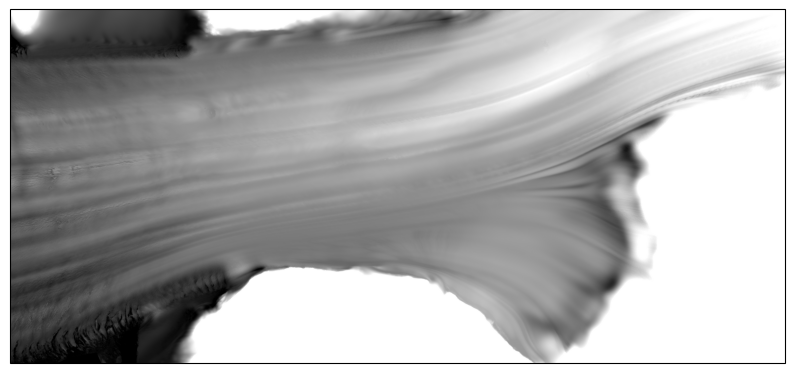

In [102]:
fig, ax = plt.subplots(figsize=(10, 8),subplot_kw={'projection': ps71_projection})
ax.imshow(rema_dat,extent=ext,cmap='gray',vmin=-50,vmax=100,zorder=0)
#bbox_limit = [left, bottom, left+10000, bottom+10000]
#ax.set_xlim(bbox_limit[0], bbox_limit[2])
#ax.set_ylim(bbox_limit[1], bbox_limit[3])

In [11]:
rema_path = '/mnt/c/Users/ZacharyKatz/Desktop/'
rema_paths = [os.path.join(rema_path, f) for f in os.listdir(rema_path) if f.startswith('REMA_2m_David')]
rema_dict = {'data': [], 'extent': []}
for remapath in rema_paths:
    with rasterio.open(remapath) as rema:
        bounds = rema.bounds
        left, bottom, right, top = bounds.left, bounds.bottom, bounds.right, bounds.top
        rema_dat = rema.read(1)
        rema_dict['data'].append(rema_dat)

    ext = (left, right, bottom, top)
    rema_dict['extent'].append(ext)



In [ ]:
fig, ax = plt.subplots(figsize=(10, 8),subplot_kw={'projection': ps71_projection})
ax.imshow(rema_dict['data'][0],extent=rema_dict['extent'][0],cmap='gray',vmin=1200,vmax=2000,zorder=0)

/tmp/ipykernel_29347/2314847061.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("magma")
/tmp/ipykernel_29347/2314847061.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("magma")
/tmp/ipykernel_29347/2314847061.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("magma")


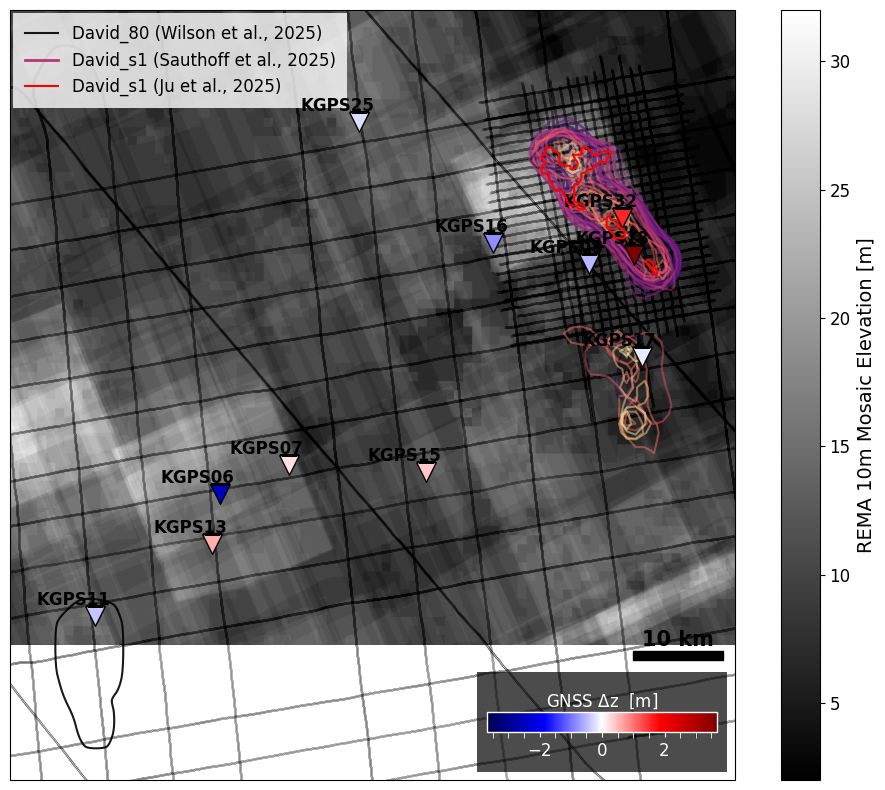

In [91]:
fig_height = 10
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig, ax = plt.subplots(
    figsize=(12, fig_height),
    subplot_kw={'projection': ps71_projection},
)

for clr, gnss_data in zip(colors_gnss, gnss_records):
    #ax.scatter(gnss_data['x'],gnss_data['y'],c=gnss_data['time'])
    ax.scatter(gnss_data['x'][0],gnss_data['y'][0],color=clr, marker='v', s=200,zorder=5, edgecolors= "black")
    ax.text(gnss_data['x'][0]-6500,gnss_data['y'][0]+1200,gnss_data['station'][0], color='black', fontsize=12,zorder=6,fontweight='bold' )

#ax.scatter(seismic['Shot_X'], seismic['Shot_Y'], s=1, c='black', label='Seismic Shots', transform=ps71_projection)
bbox = [615000,-1475000,715000,-1425000] #David_SGL2
#ax.set_xlim(bbox[0],bbox[2])
#ax.set_ylim(bbox[1],bbox[3])


paths = ['./_data/EvolvingOutlines/David_s1.geojson','./_data/EvolvingOutlines/David_s2.geojson','./_data/EvolvingOutlines/David_s3.geojson']
for evolving_path in paths:
    evolving_outlines = gpd.read_file(evolving_path)
    times = evolving_outlines["mid_pt_datetime"]

    # Convert datetimes → numeric (float seconds)
    t_num = np.array(times.astype("int64"))  # nanoseconds since epoch
        
    norm = colors.Normalize(vmin=t_num.min(), vmax=t_num.max())
    cmap = cm.get_cmap("magma")

    for outline, time in zip(evolving_outlines['geometry'], t_num):
        x_evolve, y_evolve = outline.exterior.xy
        color = cmap(norm(time))
        ax.plot(x_evolve, y_evolve, color=color,zorder=3,alpha=0.5)


# Plot radargram trace locations
#for radargram in radargrams_18_19[:]:
#    ax.scatter(radargram[0].x_coord*1, radargram[0].y_coord*1, s=0.01, color='gray', zorder=0,alpha=0.1)
#    ax.text(radargram[0].x_coord[0]*1, radargram[0].y_coord[0]*1, names_1819[radargrams_18_19.index(radargram)], color='black', fontsize=10, transform=ps71_projection, zorder=4)

#for utig_radargram in utig_grams:
#    ax.scatter(utig_radargram['x_coord'], utig_radargram['y_coord'], s=0.01, color='gray', zorder=0,alpha=0.1)


paths = [os.path.join('./_data/SarahWilsonOutlines', f) for f in os.listdir('./_data/SarahWilsonOutlines') if f.endswith('David_80_201202-202007_0.3.geojson')]
for evolving_path in paths:
    outline = gpd.read_file(evolving_path)
    # Plot outline geometry
    geom = outline.geometry.iloc[0] 
    for poly in geom.geoms:
        x,y = ll2xy(*poly.exterior.xy)
        ax.plot(x, y, color="k", zorder=2,alpha=0.9,label='David_80 (Wilson et al., 2025)')


bbox = [350000,-1605000,750000,-1320000] #David_SGL2_full
bbox = [600000,-1515000,680000,-1430000] # CLIPPED

#for rema_dat, ext in zip(rema_dict['data'][:1], rema_dict['extent'][:1]):
    #sc = ax.imshow(rema_dat,extent=ext,cmap='gray',vmin=1200,vmax=2000,zorder=0)
sc = ax.imshow(rema_dat,extent=ext,cmap='gray',vmin=2,vmax=32,zorder=0)

ax.scatter(_16_17_bedpicks['POLARX'], _16_17_bedpicks['POLARY'], s=0.001, color='black', zorder=1,alpha=0.5)
ax.scatter(_18_19_bedpicks['POLARX'], _18_19_bedpicks['POLARY'], s=0.001,color='black',zorder=1,alpha=0.5)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('REMA 10m Mosaic Elevation [m]', fontsize=14)
cbar.ax.tick_params(labelsize=12)

# Dummy magma line for legend
ax.plot(1, 1, color='#b73779', linewidth=2, label='David_s1 (Sauthoff et al., 2025)')

# Load and plot lake and seismic outlines
# Load Lake Cheongsuk shapefile
sld_path = '/mnt/c/Users/ZacharyKatz/Desktop/Research/_Semesters/25FA/KOPRI/SLD2'
pathA = sld_path + '/SLD2-A.shp'
pathB = sld_path + '/SLD2-B.shp'
pathC = sld_path + '/SLD2-C.shp'

xs = []
ys = []
for path in [pathA, pathB, pathC]:
    sf = shapefile.Reader(path)
    shapes = sf.shapes()
    for shp in shapes:
        points = shp.points
        x = [p[0] for p in points]
        y = [p[1] for p in points]
    xs.append(x)
    ys.append(y)

# Load seismic data
seismic_path = '../atl11-crossovers/_data/SeismicKSS2_21-22.csv'
seismic = pd.read_csv(seismic_path)
seismic['x'], seismic['y'] = ll2xy(seismic['LONGITUDE'], seismic['LATITUDE'])


for lake_no, (x, y) in enumerate(zip(xs, ys)):
    if lake_no == 0:
        ax.plot(x, y, color='red', linewidth=1.5, zorder=6,label='David_s1 (Ju et al., 2025)')
    else:
        ax.plot(x, y, color='red', linewidth=1.5, zorder=6)




legend = ax.legend(fontsize=12, loc='upper left',frameon=True)
legend.get_frame().set_boxstyle('square')  
legend.get_frame().set_edgecolor('none') 

ax.set_xlim(bbox[0],bbox[2])
ax.set_ylim(bbox[1],bbox[3])


# Add gps colorbar inside map



cbbox_ht = 1
percentage = cbbox_ht / fig_height

sm = cm.ScalarMappable(norm=norm_gnss, cmap=cmap_gnss)


v_cbar_anchor = (0.999, 0.001)
cbbox = inset_axes(ax, width=2.5,height=cbbox_ht,
                   bbox_to_anchor=v_cbar_anchor,
                   bbox_transform=ax.transAxes, loc="lower right")
[cbbox.spines[k].set_visible(False) for k in cbbox.spines]
cbbox.tick_params(
    axis = 'both',
    left = False,
    top = False,
    right = False,
    bottom = False,
    labelleft = False,
    labeltop = False,
    labelright = False,
    labelbottom = False
)
cbbox.set_facecolor([0,0,0,0.7])

cbaxes = inset_axes(cbbox, '92%', '20%', loc = 'center')
cbar=fig.colorbar(sm,cax=cbaxes, orientation='horizontal') #make colorbar
cbar.outline.set_edgecolor('white')
cbar.outline.set_linewidth(1)
cbar.ax.tick_params(labelsize=12, color='white', labelcolor='white')
cbar.set_label(r'GNSS $\Delta$z  [m]', fontsize=12, color='white')
cbar.ax.xaxis.set_label_position('top')

cbar.ax.minorticks_on()

cbar.ax.tick_params(which='minor', length=4, color='white')

scalebar = AnchoredSizeBar(ax.transData,
                           10000, '10 km', 'lower right', 
                           pad=0.1,
                           sep=1,
                           color='black',
                           frameon=False,
                           size_vertical=1000,
                           fontproperties=mpl.font_manager.FontProperties(size=15, weight='bold'),
                           label_top=True)

ax.add_artist(scalebar)
scalebar.set_bbox_to_anchor((0.99, percentage * 1.5), transform=ax.transAxes)



In [ ]:
from pathlib import Path
SWOT_PATH = "../swot-paper/notebooks/data/SWOT_DavidLakes"
thirty_rasters = list(Path(SWOT_PATH).glob('SWOT_L2_HR_Raster*.nc'))
thirty_rasters.sort()
for file in thirty_rasters:
    print(file)

../swot-paper/notebooks/data/SWOT_DavidLakes/SWOT_L2_HR_Raster_100m_UTM56C_N_x_x_x_040_569_007F_20251101T055556_20251101T055611_PID0_01.nc
../swot-paper/notebooks/data/SWOT_DavidLakes/SWOT_L2_HR_Raster_100m_UTM56C_N_x_x_x_041_291_007F_20251112T041850_20251112T041857_PID0_02.nc
../swot-paper/notebooks/data/SWOT_DavidLakes/SWOT_L2_HR_Raster_100m_UTM56C_N_x_x_x_041_569_007F_20251122T024059_20251122T024114_PID0_01.nc
../swot-paper/notebooks/data/SWOT_DavidLakes/SWOT_L2_HR_Raster_100m_UTM56C_N_x_x_x_042_291_007F_20251203T010354_20251203T010401_PID0_01.nc
../swot-paper/notebooks/data/SWOT_DavidLakes/SWOT_L2_HR_Raster_100m_UTM57C_N_x_x_x_040_569_008F_20251101T055610_20251101T055625_PID0_01.nc
../swot-paper/notebooks/data/SWOT_DavidLakes/SWOT_L2_HR_Raster_100m_UTM57C_N_x_x_x_041_291_008F_20251112T041856_20251112T041912_PID0_02.nc
../swot-paper/notebooks/data/SWOT_DavidLakes/SWOT_L2_HR_Raster_100m_UTM57C_N_x_x_x_041_541_007F_20251121T024025_20251121T024043_PID0_01.nc
../swot-paper/notebooks/dat

/tmp/ipykernel_29347/990186258.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("magma")
/tmp/ipykernel_29347/990186258.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("magma")
/tmp/ipykernel_29347/990186258.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("magma")


PLOTTING RASTERS
../swot-paper/notebooks/data/SWOT_DavidLakes/SWOT_L2_HR_Raster_100m_UTM57C_N_x_x_x_041_541_007F_20251121T024025_20251121T024043_PID0_01.nc
../swot-paper/notebooks/data/SWOT_DavidLakes/SWOT_L2_HR_Raster_100m_UTM57C_N_x_x_x_041_541_008F_20251121T024042_20251121T024103_PID0_01.nc
../swot-paper/notebooks/data/SWOT_DavidLakes/SWOT_L2_HR_Raster_100m_UTM58C_N_x_x_x_041_541_009F_20251121T024102_20251121T024104_PID0_01.nc


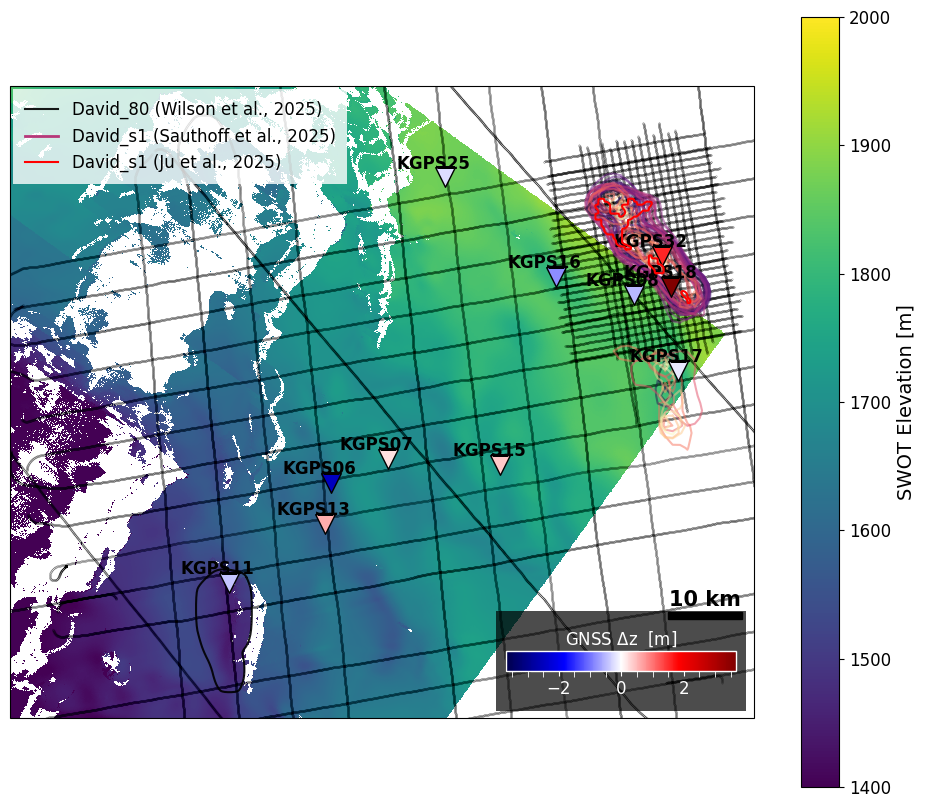

In [28]:
# Plot with SWOT

fig_height = 10
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig, ax = plt.subplots(
    figsize=(12, fig_height),
    subplot_kw={'projection': ps71_projection},
)

for clr, gnss_data in zip(colors_gnss, gnss_records):
    #ax.scatter(gnss_data['x'],gnss_data['y'],c=gnss_data['time'])
    ax.scatter(gnss_data['x'][0],gnss_data['y'][0],color=clr, marker='v', s=200,zorder=5, edgecolors= "black")
    ax.text(gnss_data['x'][0]-6500,gnss_data['y'][0]+1200,gnss_data['station'][0], color='black', fontsize=12,zorder=6,fontweight='bold' )

#ax.scatter(seismic['Shot_X'], seismic['Shot_Y'], s=1, c='black', label='Seismic Shots', transform=ps71_projection)
bbox = [615000,-1475000,715000,-1425000] #David_SGL2
#ax.set_xlim(bbox[0],bbox[2])
#ax.set_ylim(bbox[1],bbox[3])


paths = ['./_data/EvolvingOutlines/David_s1.geojson','./_data/EvolvingOutlines/David_s2.geojson','./_data/EvolvingOutlines/David_s3.geojson']
for evolving_path in paths:
    evolving_outlines = gpd.read_file(evolving_path)
    times = evolving_outlines["mid_pt_datetime"]

    # Convert datetimes → numeric (float seconds)
    t_num = np.array(times.astype("int64"))  # nanoseconds since epoch
        
    norm = colors.Normalize(vmin=t_num.min(), vmax=t_num.max())
    cmap = cm.get_cmap("magma")

    for outline, time in zip(evolving_outlines['geometry'], t_num):
        x_evolve, y_evolve = outline.exterior.xy
        color = cmap(norm(time))
        ax.plot(x_evolve, y_evolve, color=color,zorder=3,alpha=0.5)


# Plot radargram trace locations
#for radargram in radargrams_18_19[:]:
#    ax.scatter(radargram[0].x_coord*1, radargram[0].y_coord*1, s=0.01, color='gray', zorder=0,alpha=0.1)
#    ax.text(radargram[0].x_coord[0]*1, radargram[0].y_coord[0]*1, names_1819[radargrams_18_19.index(radargram)], color='black', fontsize=10, transform=ps71_projection, zorder=4)

#for utig_radargram in utig_grams:
#    ax.scatter(utig_radargram['x_coord'], utig_radargram['y_coord'], s=0.01, color='gray', zorder=0,alpha=0.1)


paths = [os.path.join('./_data/SarahWilsonOutlines', f) for f in os.listdir('./_data/SarahWilsonOutlines') if f.endswith('David_80_201202-202007_0.3.geojson')]
for evolving_path in paths:
    outline = gpd.read_file(evolving_path)
    # Plot outline geometry
    geom = outline.geometry.iloc[0] 
    for poly in geom.geoms:
        x,y = ll2xy(*poly.exterior.xy)
        ax.plot(x, y, color="k", zorder=2,alpha=0.9,label='David_80 (Wilson et al., 2025)')


bbox = [350000,-1605000,750000,-1320000] #David_SGL2_full
bbox = [580000,-1515000,680000,-1430000] # CLIPPED

ax.scatter(_16_17_bedpicks['POLARX'], _16_17_bedpicks['POLARY'], s=0.001, color='black', zorder=1,alpha=0.5)
ax.scatter(_18_19_bedpicks['POLARX'], _18_19_bedpicks['POLARY'], s=0.001,color='black',zorder=1,alpha=0.5)

# Dummy magma line for legend
ax.plot(1, 1, color='#b73779', linewidth=2, label='David_s1 (Sauthoff et al., 2025)')

# Load and plot lake and seismic outlines
# Load Lake Cheongsuk shapefile
sld_path = '/mnt/c/Users/ZacharyKatz/Desktop/Research/_Semesters/25FA/KOPRI/SLD2'
pathA = sld_path + '/SLD2-A.shp'
pathB = sld_path + '/SLD2-B.shp'
pathC = sld_path + '/SLD2-C.shp'

xs = []
ys = []
for path in [pathA, pathB, pathC]:
    sf = shapefile.Reader(path)
    shapes = sf.shapes()
    for shp in shapes:
        points = shp.points
        x = [p[0] for p in points]
        y = [p[1] for p in points]
    xs.append(x)
    ys.append(y)

# Load seismic data
seismic_path = '../atl11-crossovers/_data/SeismicKSS2_21-22.csv'
seismic = pd.read_csv(seismic_path)
seismic['x'], seismic['y'] = ll2xy(seismic['LONGITUDE'], seismic['LATITUDE'])


for lake_no, (x, y) in enumerate(zip(xs, ys)):
    if lake_no == 0:
        ax.plot(x, y, color='red', linewidth=1.5, zorder=6,label='David_s1 (Ju et al., 2025)')
    else:
        ax.plot(x, y, color='red', linewidth=1.5, zorder=6)

print("PLOTTING RASTERS")
to_plot = 'wse'
label = "Elevation [m]"
vmin = 1400
vmax = 2000
cycle_plot = '041'
track_plot = '541'

for file in thirty_rasters[:]:
    # Check if includes 
    trk_cycle = f"{cycle_plot}_{track_plot}"
    if trk_cycle in str(file):
        print(file)
        ds = xr.open_mfdataset(file,combine='nested',concat_dim="num_lines", decode_times=False,engine="h5netcdf")
        wse = ds[to_plot].isel(num_lines=0)

        utm = ccrs.UTM(zone=ds.utm_zone_num, southern_hemisphere=True)
        x = wse['x'].values
        y = wse['y'].values

        X, Y = np.meshgrid(x, y)
        mesh = ax.pcolormesh(
        X, Y, wse.values,
        transform=utm,
        cmap='viridis',
        shading='auto',
        vmin=vmin,
        vmax=vmax,
        zorder=0,
        )

cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label('SWOT Elevation [m]', fontsize=14)
cbar.ax.tick_params(labelsize=12)


legend = ax.legend(fontsize=12, loc='upper left',frameon=True)
legend.get_frame().set_boxstyle('square')  
legend.get_frame().set_edgecolor('none') 

ax.set_xlim(bbox[0],bbox[2])
ax.set_ylim(bbox[1],bbox[3])


# Add gps colorbar inside map
cbbox_ht = 1
percentage = cbbox_ht / fig_height

sm = cm.ScalarMappable(norm=norm_gnss, cmap=cmap_gnss)


v_cbar_anchor = (0.999, 0.001)
cbbox = inset_axes(ax, width=2.5,height=cbbox_ht,
                   bbox_to_anchor=v_cbar_anchor,
                   bbox_transform=ax.transAxes, loc="lower right")
[cbbox.spines[k].set_visible(False) for k in cbbox.spines]
cbbox.tick_params(
    axis = 'both',
    left = False,
    top = False,
    right = False,
    bottom = False,
    labelleft = False,
    labeltop = False,
    labelright = False,
    labelbottom = False
)
cbbox.set_facecolor([0,0,0,0.7])

cbaxes = inset_axes(cbbox, '92%', '20%', loc = 'center')
cbar=fig.colorbar(sm,cax=cbaxes, orientation='horizontal') #make colorbar
cbar.outline.set_edgecolor('white')
cbar.outline.set_linewidth(1)
cbar.ax.tick_params(labelsize=12, color='white', labelcolor='white')
cbar.set_label(r'GNSS $\Delta$z  [m]', fontsize=12, color='white')
cbar.ax.xaxis.set_label_position('top')

cbar.ax.minorticks_on()

cbar.ax.tick_params(which='minor', length=4, color='white')

scalebar = AnchoredSizeBar(ax.transData,
                           10000, '10 km', 'lower right', 
                           pad=0.1,
                           sep=1,
                           color='black',
                           frameon=False,
                           size_vertical=1000,
                           fontproperties=mpl.font_manager.FontProperties(size=15, weight='bold'),
                           label_top=True)

ax.add_artist(scalebar)
scalebar.set_bbox_to_anchor((0.99, percentage * 1.5), transform=ax.transAxes)



/tmp/ipykernel_29347/651351932.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("magma")
/tmp/ipykernel_29347/651351932.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("magma")
/tmp/ipykernel_29347/651351932.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("magma")


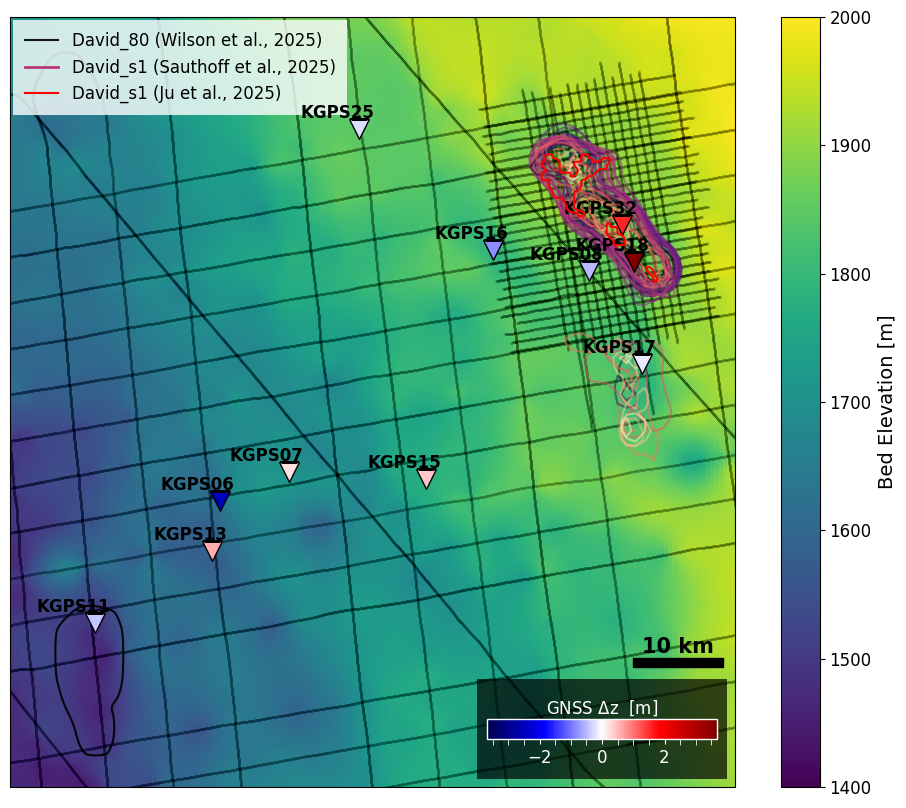

In [36]:
fig_height = 10
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig, ax = plt.subplots(
    figsize=(12, fig_height),
    subplot_kw={'projection': ps71_projection},
)

for clr, gnss_data in zip(colors_gnss, gnss_records):
    #ax.scatter(gnss_data['x'],gnss_data['y'],c=gnss_data['time'])
    ax.scatter(gnss_data['x'][0],gnss_data['y'][0],color=clr, marker='v', s=200,zorder=5, edgecolors= "black")
    ax.text(gnss_data['x'][0]-6500,gnss_data['y'][0]+1200,gnss_data['station'][0], color='black', fontsize=12,zorder=6,fontweight='bold' )

#ax.scatter(seismic['Shot_X'], seismic['Shot_Y'], s=1, c='black', label='Seismic Shots', transform=ps71_projection)
bbox = [615000,-1475000,715000,-1425000] #David_SGL2
#ax.set_xlim(bbox[0],bbox[2])
#ax.set_ylim(bbox[1],bbox[3])


paths = ['./_data/EvolvingOutlines/David_s1.geojson','./_data/EvolvingOutlines/David_s2.geojson','./_data/EvolvingOutlines/David_s3.geojson']
for evolving_path in paths:
    evolving_outlines = gpd.read_file(evolving_path)
    times = evolving_outlines["mid_pt_datetime"]

    # Convert datetimes → numeric (float seconds)
    t_num = np.array(times.astype("int64"))  # nanoseconds since epoch
        
    norm = colors.Normalize(vmin=t_num.min(), vmax=t_num.max())
    cmap = cm.get_cmap("magma")

    for outline, time in zip(evolving_outlines['geometry'], t_num):
        x_evolve, y_evolve = outline.exterior.xy
        color = cmap(norm(time))
        ax.plot(x_evolve, y_evolve, color=color,zorder=3,alpha=0.5)


# Plot radargram trace locations
#for radargram in radargrams_18_19[:]:
#    ax.scatter(radargram[0].x_coord*1, radargram[0].y_coord*1, s=0.01, color='gray', zorder=0,alpha=0.1)
#    ax.text(radargram[0].x_coord[0]*1, radargram[0].y_coord[0]*1, names_1819[radargrams_18_19.index(radargram)], color='black', fontsize=10, transform=ps71_projection, zorder=4)

#for utig_radargram in utig_grams:
#    ax.scatter(utig_radargram['x_coord'], utig_radargram['y_coord'], s=0.01, color='gray', zorder=0,alpha=0.1)


paths = [os.path.join('./_data/SarahWilsonOutlines', f) for f in os.listdir('./_data/SarahWilsonOutlines') if f.endswith('David_80_201202-202007_0.3.geojson')]
for evolving_path in paths:
    outline = gpd.read_file(evolving_path)
    # Plot outline geometry
    geom = outline.geometry.iloc[0] 
    for poly in geom.geoms:
        x,y = ll2xy(*poly.exterior.xy)
        ax.plot(x, y, color="k", zorder=2,alpha=0.9,label='David_80 (Wilson et al., 2025)')


bbox = [350000,-1605000,750000,-1320000] #David_SGL2_full
bbox = [600000,-1515000,680000,-1430000] # CLIPPED

sc = ax.pcolormesh(
    gridx, gridy, z_kriged,
    cmap=cmap_radar,
    norm=norm_radar,
    shading='auto',
    zorder=0
)

ax.scatter(_16_17_bedpicks['POLARX'], _16_17_bedpicks['POLARY'], s=0.001, color='black', zorder=1,alpha=0.5)
ax.scatter(_18_19_bedpicks['POLARX'], _18_19_bedpicks['POLARY'], s=0.001,color='black',zorder=1,alpha=0.5)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Bed Elevation [m]', fontsize=14)
cbar.ax.tick_params(labelsize=12)

# Dummy magma line for legend
ax.plot(1, 1, color='#b73779', linewidth=2, label='David_s1 (Sauthoff et al., 2025)')

# Load and plot lake and seismic outlines
# Load Lake Cheongsuk shapefile
sld_path = '/mnt/c/Users/ZacharyKatz/Desktop/Research/_Semesters/25FA/KOPRI/SLD2'
pathA = sld_path + '/SLD2-A.shp'
pathB = sld_path + '/SLD2-B.shp'
pathC = sld_path + '/SLD2-C.shp'

xs = []
ys = []
for path in [pathA, pathB, pathC]:
    sf = shapefile.Reader(path)
    shapes = sf.shapes()
    for shp in shapes:
        points = shp.points
        x = [p[0] for p in points]
        y = [p[1] for p in points]
    xs.append(x)
    ys.append(y)

# Load seismic data
seismic_path = '../atl11-crossovers/_data/SeismicKSS2_21-22.csv'
seismic = pd.read_csv(seismic_path)
seismic['x'], seismic['y'] = ll2xy(seismic['LONGITUDE'], seismic['LATITUDE'])


for lake_no, (x, y) in enumerate(zip(xs, ys)):
    if lake_no == 0:
        ax.plot(x, y, color='red', linewidth=1.5, zorder=6,label='David_s1 (Ju et al., 2025)')
    else:
        ax.plot(x, y, color='red', linewidth=1.5, zorder=6)




legend = ax.legend(fontsize=12, loc='upper left',frameon=True)
legend.get_frame().set_boxstyle('square')  
legend.get_frame().set_edgecolor('none') 

ax.set_xlim(bbox[0],bbox[2])
ax.set_ylim(bbox[1],bbox[3])


# Add gps colorbar inside map



cbbox_ht = 1
percentage = cbbox_ht / fig_height

sm = cm.ScalarMappable(norm=norm_gnss, cmap=cmap_gnss)


v_cbar_anchor = (0.999, 0.001)
cbbox = inset_axes(ax, width=2.5,height=cbbox_ht,
                   bbox_to_anchor=v_cbar_anchor,
                   bbox_transform=ax.transAxes, loc="lower right")
[cbbox.spines[k].set_visible(False) for k in cbbox.spines]
cbbox.tick_params(
    axis = 'both',
    left = False,
    top = False,
    right = False,
    bottom = False,
    labelleft = False,
    labeltop = False,
    labelright = False,
    labelbottom = False
)
cbbox.set_facecolor([0,0,0,0.7])

cbaxes = inset_axes(cbbox, '92%', '20%', loc = 'center')
cbar=fig.colorbar(sm,cax=cbaxes, orientation='horizontal') #make colorbar
cbar.outline.set_edgecolor('white')
cbar.outline.set_linewidth(1)
cbar.ax.tick_params(labelsize=12, color='white', labelcolor='white')
cbar.set_label(r'GNSS $\Delta$z  [m]', fontsize=12, color='white')
cbar.ax.xaxis.set_label_position('top')

cbar.ax.minorticks_on()

cbar.ax.tick_params(which='minor', length=4, color='white')

scalebar = AnchoredSizeBar(ax.transData,
                           10000, '10 km', 'lower right', 
                           pad=0.1,
                           sep=1,
                           color='black',
                           frameon=False,
                           size_vertical=1000,
                           fontproperties=mpl.font_manager.FontProperties(size=15, weight='bold'),
                           label_top=True)

ax.add_artist(scalebar)
scalebar.set_bbox_to_anchor((0.99, percentage * 1.5), transform=ax.transAxes)



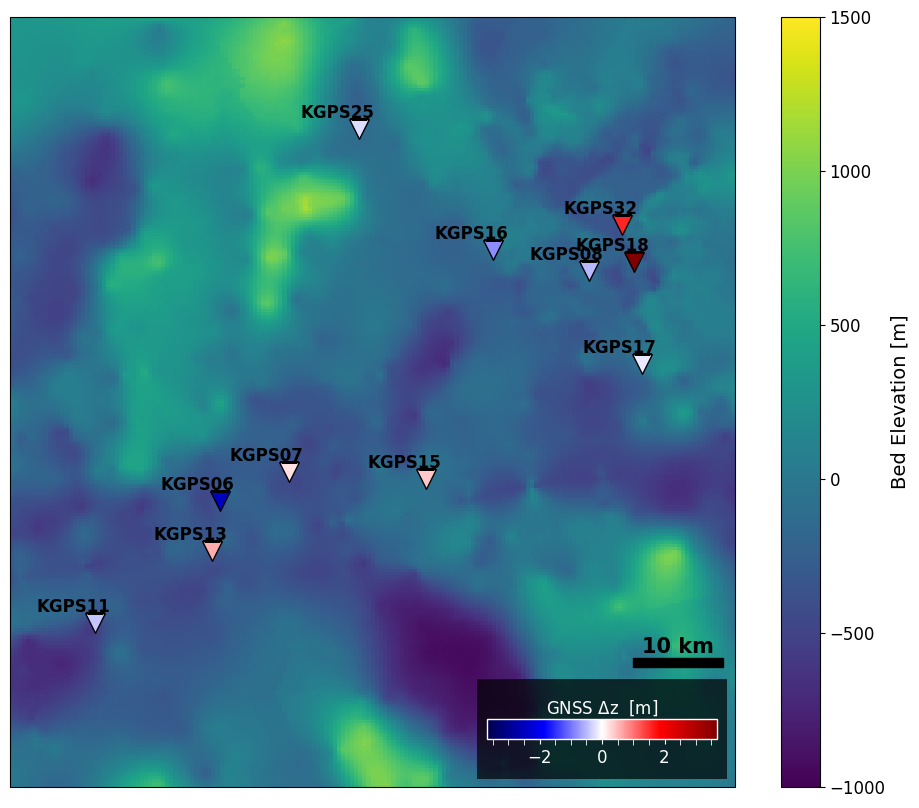

In [63]:
fig_height = 10
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig, ax = plt.subplots(
    figsize=(12, fig_height),
    subplot_kw={'projection': ps71_projection},
)

for clr, gnss_data in zip(colors_gnss, gnss_records):
    #ax.scatter(gnss_data['x'],gnss_data['y'],c=gnss_data['time'])
    ax.scatter(gnss_data['x'][0],gnss_data['y'][0],color=clr, marker='v', s=200,zorder=5, edgecolors= "black")
    ax.text(gnss_data['x'][0]-6500,gnss_data['y'][0]+1200,gnss_data['station'][0], color='black', fontsize=12,zorder=6,fontweight='bold' )

#ax.scatter(seismic['Shot_X'], seismic['Shot_Y'], s=1, c='black', label='Seismic Shots', transform=ps71_projection)
bbox = [615000,-1475000,715000,-1425000] #David_SGL2
#ax.set_xlim(bbox[0],bbox[2])
#ax.set_ylim(bbox[1],bbox[3])

# Plot radargram trace locations
#for radargram in radargrams_18_19[:]:
#    ax.scatter(radargram[0].x_coord*1, radargram[0].y_coord*1, s=0.01, color='gray', zorder=0,alpha=0.1)
#    ax.text(radargram[0].x_coord[0]*1, radargram[0].y_coord[0]*1, names_1819[radargrams_18_19.index(radargram)], color='black', fontsize=10, transform=ps71_projection, zorder=4)

#for utig_radargram in utig_grams:
#    ax.scatter(utig_radargram['x_coord'], utig_radargram['y_coord'], s=0.01, color='gray', zorder=0,alpha=0.1)


bbox = [350000,-1605000,750000,-1320000] #David_SGL2_full
bbox = [600000,-1515000,680000,-1430000]

sc = ax.pcolormesh(
    gridx, gridy, z_kriged,
    cmap=cmap_radar,
    norm=norm_radar,
    shading='auto',
    zorder=0
)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Bed Elevation [m]', fontsize=14)
cbar.ax.tick_params(labelsize=12)

ax.set_xlim(bbox[0],bbox[2])
ax.set_ylim(bbox[1],bbox[3])


# Add gps colorbar inside map



cbbox_ht = 1
percentage = cbbox_ht / fig_height

sm = cm.ScalarMappable(norm=norm_gnss, cmap=cmap_gnss)


v_cbar_anchor = (0.999, 0.001)
cbbox = inset_axes(ax, width=2.5,height=cbbox_ht,
                   bbox_to_anchor=v_cbar_anchor,
                   bbox_transform=ax.transAxes, loc="lower right")
[cbbox.spines[k].set_visible(False) for k in cbbox.spines]
cbbox.tick_params(
    axis = 'both',
    left = False,
    top = False,
    right = False,
    bottom = False,
    labelleft = False,
    labeltop = False,
    labelright = False,
    labelbottom = False
)
cbbox.set_facecolor([0,0,0,0.7])

cbaxes = inset_axes(cbbox, '92%', '20%', loc = 'center')
cbar=fig.colorbar(sm,cax=cbaxes, orientation='horizontal') #make colorbar
cbar.outline.set_edgecolor('white')
cbar.outline.set_linewidth(1)
cbar.ax.tick_params(labelsize=12, color='white', labelcolor='white')
cbar.set_label(r'GNSS $\Delta$z  [m]', fontsize=12, color='white')
cbar.ax.xaxis.set_label_position('top')

cbar.ax.minorticks_on()

cbar.ax.tick_params(which='minor', length=4, color='white')

scalebar = AnchoredSizeBar(ax.transData,
                           10000, '10 km', 'lower right', 
                           pad=0.1,
                           sep=1,
                           color='black',
                           frameon=False,
                           size_vertical=1000,
                           fontproperties=mpl.font_manager.FontProperties(size=15, weight='bold'),
                           label_top=True)

ax.add_artist(scalebar)
scalebar.set_bbox_to_anchor((0.99, percentage * 1.5), transform=ax.transAxes)



In [97]:
test_gram['fasttime'].values #ns
# Convert to m with v_radar 0.169 m/ns
fasttime_m = test_gram['fasttime'].values * 0.169 / 2 #Two way travel time
fasttime_m = fasttime_m.astype('timedelta64[ns]').astype(np.int64)
fasttime_m

alt = test_gram['altitude'].values            # (time,)
fd  = fasttime_m          # (fasttime_dim,)

# Elevation grid: (time, fasttime_dim)
elev = alt[:, None] - fd[None, :]
amp = test_gram['amplitude_high_gain'].values
x0 = float(test_gram['x_coord'].values[0])
y0 = float(test_gram['y_coord'].values[0])

dist_along_track = np.sqrt(
    (test_gram['x_coord'].values - x0)**2 +
    (test_gram['y_coord'].values - y0)**2
)


(4000,) (4000, 3200) (4000, 3200)


TypeError: Incompatible X, Y inputs to pcolormesh; see help(pcolormesh)

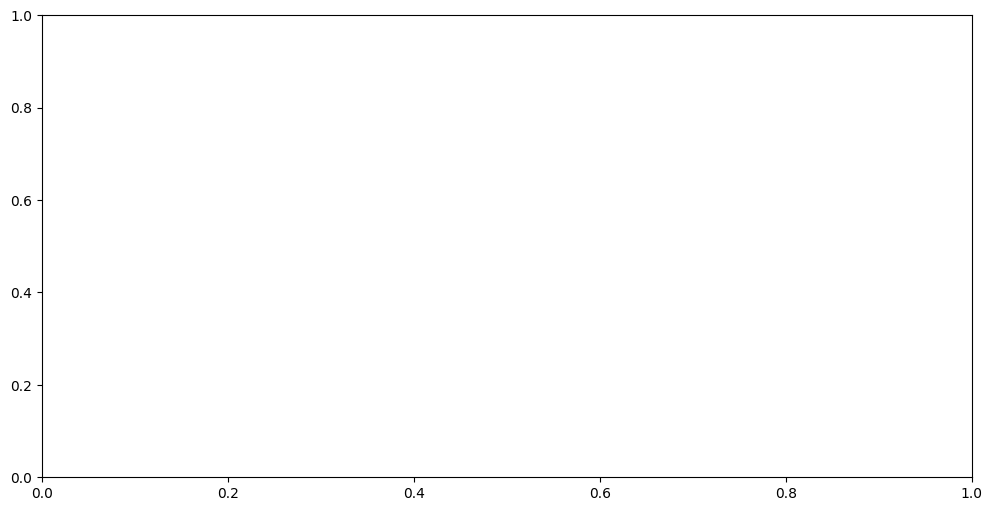

In [100]:
fig, ax = plt.subplots(figsize=(12, 6))
print(dist_along_track.shape, elev.shape, amp.shape)

pcm = ax.pcolormesh(
    dist_along_track,
    elev,
    amp,
    shading='auto',
    cmap='gray'
)

ax.set_ylabel('Elevation [m]')
ax.set_xlabel('Distance Along Track [m]')
ax.invert_yaxis()


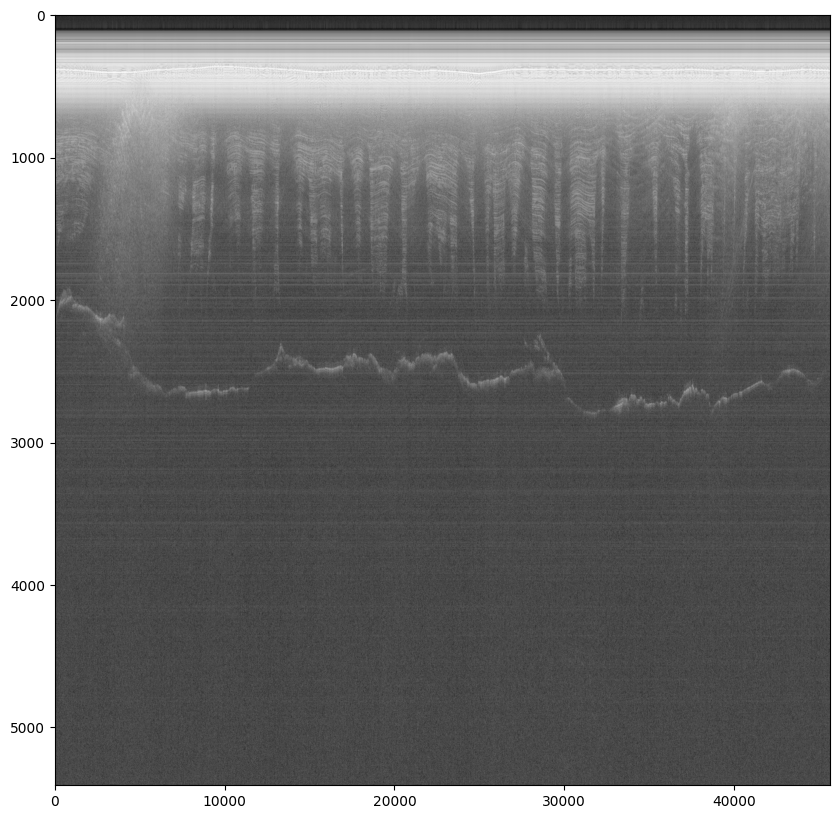

In [ ]:
x = next(
    i for i, ds in enumerate(utig_grams)
    if 'GL0328c_001' in ds.attrs.get('granule_id', '')
)

test_gram = utig_grams[x]

# Test plot
fig, ax = plt.subplots(figsize=(10, 10))
x0 = float(test_gram['x_coord'].values[0])
y0 = float(test_gram['y_coord'].values[0])

dist_along_track = np.sqrt(
    (test_gram['x_coord'].values - x0)**2 +
    (test_gram['y_coord'].values - y0)**2
)

ax.imshow(test_gram['amplitude_high_gain'].T, aspect='auto', cmap='gray', extent=[dist_along_track[0], dist_along_track[-1], fasttime_m[-1], fasttime_m[0]])

#

In [ ]:

# Test plot
fig, ax = plt.subplots(figsize=(10, 10))
x0 = float(test_gram['x_coord'].values[0])
y0 = float(test_gram['y_coord'].values[0])

dist_along_track = np.sqrt(
    (test_gram['x_coord'].values - x0)**2 +
    (test_gram['y_coord'].values - y0)**2
)
fasttime_sec = test_gram['fasttime'].dt.total_seconds().values * 1e9 #Convert to nanoseconds

ax.imshow(test_gram['amplitude_high_gain'].T, aspect='auto', cmap='gray', extent=[dist_along_track[0], dist_along_track[-1], fasttime_sec[-1], fasttime_sec[0]])

#

(-1515000.0, -1430000.0)

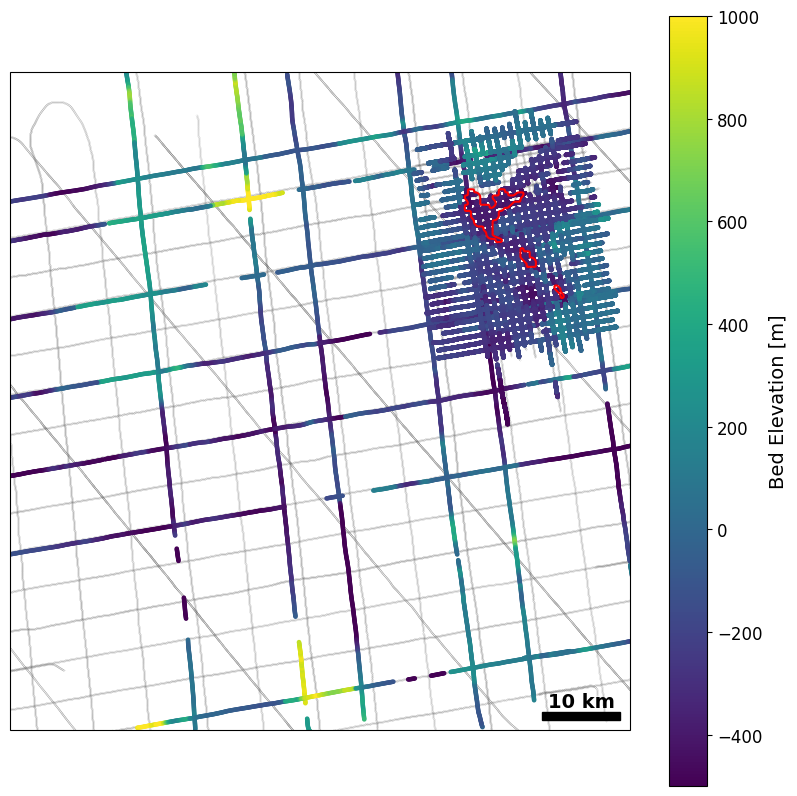

In [49]:
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig, ax = plt.subplots(
    figsize=(10, 10),
    subplot_kw={'projection': ps71_projection},
)

# Load and plot lake and seismic outlines
# Load Lake Cheongsuk shapefile
sld_path = '/mnt/c/Users/ZacharyKatz/Desktop/Research/_Semesters/25FA/KOPRI/SLD2'
pathA = sld_path + '/SLD2-A.shp'
pathB = sld_path + '/SLD2-B.shp'
pathC = sld_path + '/SLD2-C.shp'

xs = []
ys = []
for path in [pathA, pathB, pathC]:
    sf = shapefile.Reader(path)
    shapes = sf.shapes()
    for shp in shapes:
        points = shp.points
        x = [p[0] for p in points]
        y = [p[1] for p in points]
    xs.append(x)
    ys.append(y)

# Load seismic data
seismic_path = '../atl11-crossovers/_data/SeismicKSS2_21-22.csv'
seismic = pd.read_csv(seismic_path)
seismic['x'], seismic['y'] = ll2xy(seismic['LONGITUDE'], seismic['LATITUDE'])


for x, y in zip(xs, ys):
    ax.plot(x, y, color='red', linewidth=1.5)

scalebar = AnchoredSizeBar(ax.transData,
                           10000, '10 km', 'lower right', 
                           pad=0.1,
                           sep=1,
                           color='black',
                           frameon=False,
                           size_vertical=1000,
                           fontproperties=mpl.font_manager.FontProperties(size=14, weight='bold'),
                           label_top=True)

ax.add_artist(scalebar)
scalebar.set_bbox_to_anchor((0.99, 0.01), transform=ax.transAxes)

# Plot radargram trace locations
for radargram in radargrams_18_19[:]:
    ax.scatter(radargram[0].x_coord*1, radargram[0].y_coord*1, s=0.01, color='gray', zorder=0,alpha=0.1)
#    ax.text(radargram[0].x_coord[0]*1, radargram[0].y_coord[0]*1, names_1819[radargrams_18_19.index(radargram)], color='black', fontsize=10, transform=ps71_projection, zorder=4)

#for radargram in radargrams_16_17[:]:
#    ax.scatter(radargram[0].x_coord*1, radargram[0].y_coord*1, s=0.01, color='gray', zorder=0,alpha=0.1)


for utig_radargram in utig_grams:
    ax.scatter(utig_radargram['x_coord'], utig_radargram['y_coord'], s=0.01, color='gray', zorder=0,alpha=0.1)


bbox = [350000,-1605000,750000,-1320000] #David_SGL2_full
bbox = [600000,-1515000,680000,-1430000]

sc = ax.scatter(_16_17_bedpicks['PolarX'], _16_17_bedpicks['PolarY'], c=_16_17_bedpicks['bedele'], s=5, cmap=cmap, norm=norm, label='2016-2017 Bed Picks')
ax.scatter(_18_19_bedpicks['POLARX'], _18_19_bedpicks['POLARY'], c=_18_19_bedpicks['BED_ELV'], s=5,cmap=cmap, norm=norm, label='2018-2019 Bed Picks')

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Bed Elevation [m]', fontsize=14)
cbar.ax.tick_params(labelsize=12)

ax.set_xlim(bbox[0],bbox[2])
ax.set_ylim(bbox[1],bbox[3])





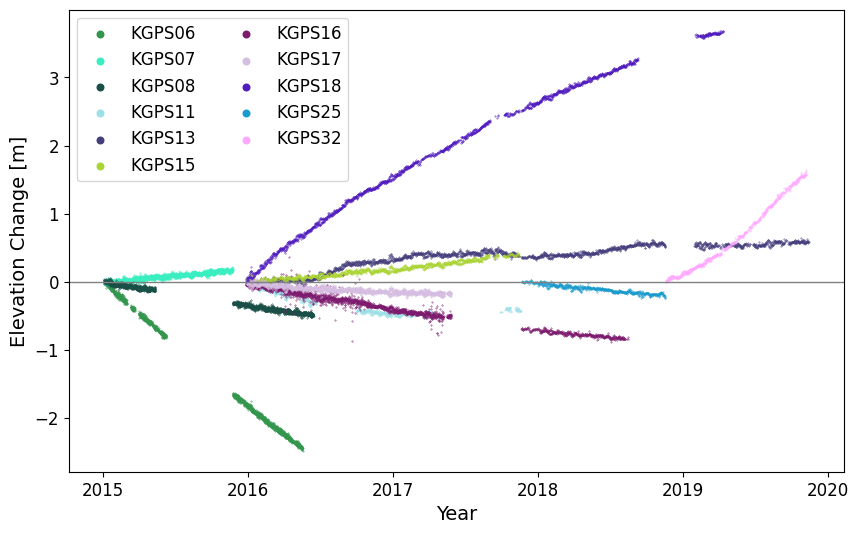

In [21]:
# Change in elevation v time for all stations
fig, ax = plt.subplots(figsize=(10, 6))

ax.axhline(0, color='gray', linestyle='-', linewidth=1)
colors = ['#32964d', '#39eec0', '#194f46', '#9be0e6', '#453e7d', '#abd533', '#7d1a6e', '#d6bee2', '#501bbf', '#199bce', '#ffa8ff']
for gnss_data, color in zip(gnss_records, colors):
    ax.scatter(gnss_data['datetime'], gnss_data['z'] - gnss_data['z'][0], label=gnss_data['station'][0], color=color, s=0.1)

ax.legend(fontsize=12, markerscale=15,ncol=2)

ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("Elevation Change [m]", fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=12)


In [19]:
import scipy
# Find instantaneous velocity and smooth
def derivative(time, x_col, freq):
    """
    Compute the first and second derivative of a smoothed time series
    Parameters
    time - event with times
    x_col - column of x values of which to take the derivative of

    Returns
    grad - First derivative [list]
    grad2 - Second derivative [list]
    """
    y_data = x_col - np.mean(x_col)
    # print(x_data,y_data)
    try:
        b, a = scipy.signal.butter(4, freq, "low")
        filtered = scipy.signal.filtfilt(b, a, y_data, padlen=50)
        grad = np.gradient(filtered, 60*12)

        b, a = scipy.signal.butter(4, 0.05)
        grad_filtered = scipy.signal.filtfilt(b, a, grad, padlen=50)
        grad2 = np.gradient(np.gradient(grad_filtered), 60*12)
    except ValueError:
        grad = np.full(len(y_data), np.nan)
        grad2 = np.full(len(y_data), np.nan)
    return grad, grad2



In [31]:

v_float = gnss_data['v'].astype(float)
~np.isnan(v_float)

0       True
1       True
2       True
3       True
4       True
        ... 
1866    True
1867    True
1868    True
1869    True
1870    True
Name: v, Length: 1871, dtype: bool

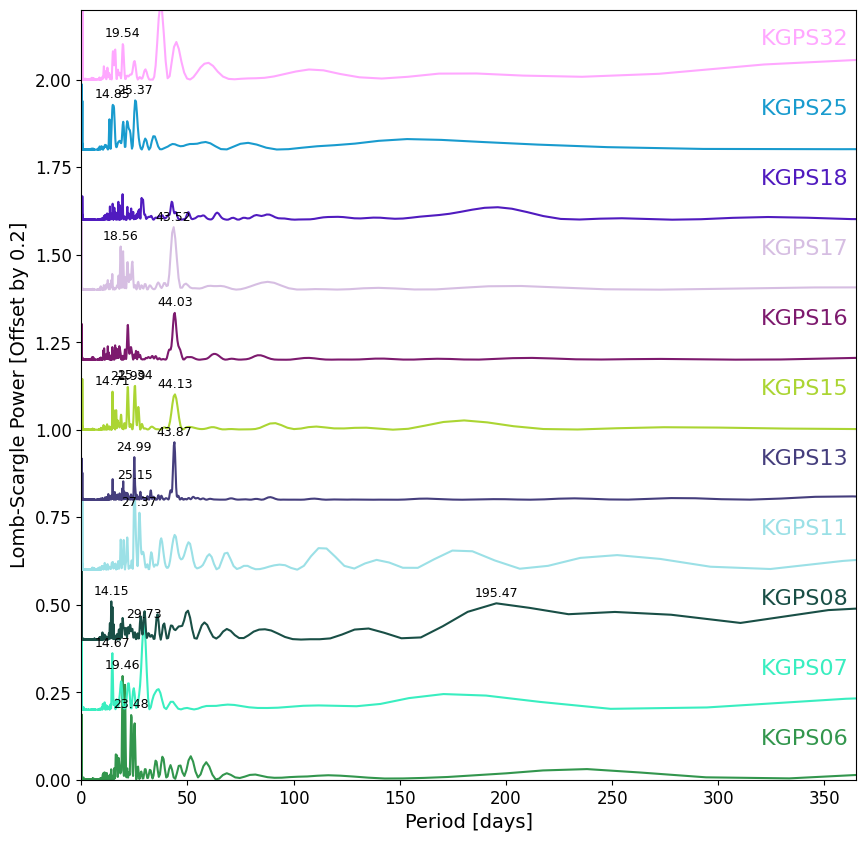

In [44]:
from astropy.timeseries import LombScargle

fig, ax = plt.subplots(figsize=(10, 10),)
offset=0
for color, gnss_data in zip(colors, gnss_records):
    g1, g2 = derivative(gnss_data['time'], gnss_data["h_displacement"], 0.05)
    gnss_data['velocity'] = g1
    
    """
    fig, ax = plt.subplots(
        figsize=(10, 10),
    )
    gnss_data['velocity'] = g1
    ax.scatter(gnss_data['datetime'],gnss_data['velocity'] )
    ax.set_xlabel('Datetime')
    ax.set_ylabel('V [m/day]')
    """

    # Lomb scargke of datetune vel
    from astropy.timeseries import LombScargle
    # Convert datetime to seconds
    dates_as_sec_from2015 = np.array([(dt - pd.Timestamp('2015-01-01')).total_seconds() for dt in gnss_data['datetime']])
    # Mask NaN values

    v_float = gnss_data['v'].astype(float)
    mask = ~np.isnan(v_float)
    dates_as_sec_masked = dates_as_sec_from2015[mask]
    avg_vel_detrended = v_float[mask]

    velocity = gnss_data['v']
    frequency, power = LombScargle(dates_as_sec_masked, avg_vel_detrended).autopower()
    period = 1 / frequency / 3600 / 24  # days
    ax.plot(period, power + offset, color=color, label=gnss_data['station'][0])
    ax.text(320, offset + 0.1, gnss_data['station'][0], color=color, fontsize=16)

    # Pick peak on power
    peaks, props = scipy.signal.find_peaks(power, height=0.1, distance=10)
    for i in peaks:
        if (period[i]) > 5:
            ax.annotate(
            f"{period[i]:.2f}",              # format as needed
            (period[i], power[i]+offset),
            xytext=(0, 5),
            textcoords='offset points',
            ha='center',
            fontsize=9
        )
        

    offset += 0.2


    ax.set_xlim(0, 365)
    ax.set_ylim(0,2.2)

    ax.set_xlabel("Period [days]", fontsize=14)
    ax.set_ylabel("Lomb-Scargle Power [Offset by 0.2]", fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)


TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

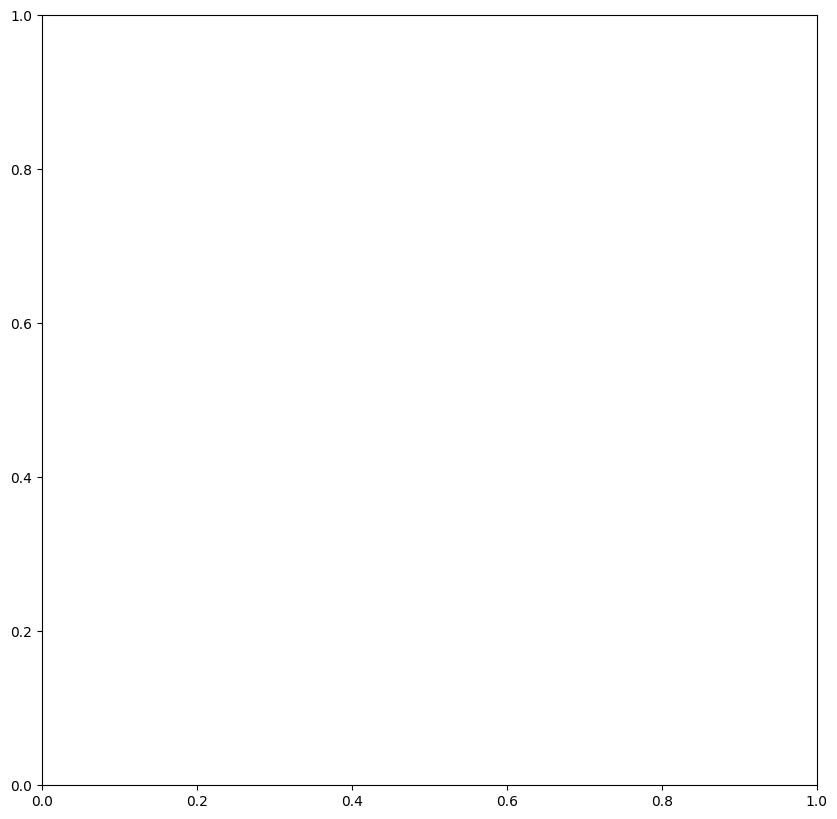

In [ ]:
from astropy.timeseries import LombScargle

fig, ax = plt.subplots(figsize=(10, 10),)
offset=0
for color, gnss_data in zip(colors, gnss_records):
    g1, g2 = derivative(gnss_data['time'], gnss_data["h_displacement"], 0.05)
    gnss_data['velocity'] = g1
    
    """
    fig, ax = plt.subplots(
        figsize=(10, 10),
    )
    gnss_data['velocity'] = g1
    ax.scatter(gnss_data['datetime'],gnss_data['velocity'] )
    ax.set_xlabel('Datetime')
    ax.set_ylabel('V [m/day]')
    """

    # Lomb scargke of datetune vel
    from astropy.timeseries import LombScargle
    # Convert datetime to seconds
    dates_as_sec_from2015 = np.array([(dt - pd.Timestamp('2015-01-01')).total_seconds() for dt in gnss_data['datetime']])
    # Mask NaN values
    mask = ~np.isnan(gnss_data['velocity'])
    dates_as_sec_masked = dates_as_sec_from2015[mask]
    avg_vel_detrended = gnss_data['velocity'][mask]

    velocity = gnss_data['velocity']
    frequency, power = LombScargle(dates_as_sec_masked, avg_vel_detrended).autopower()
    period = 1 / frequency / 3600 / 24  # days
    ax.plot(period, power + offset, color=color, label=gnss_data['station'][0])
    ax.text(320, offset + 0.1, gnss_data['station'][0], color=color, fontsize=16)
    offset += 0.2

    ax.set_xlim(0, 365)
    ax.set_ylim(0,2.2)

    ax.set_xlabel("Period [days]", fontsize=14)
    ax.set_ylabel("Lomb-Scargle Power [Offset by 0.2]", fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
